# **Bank GoodCredit — Credit Risk Assessment & Scoring**

##### **Project Type** - Classification / Credit Risk Ranking
##### **Contribution** - **Individual**
##### **Team Member** - **HEMAA SHRI G**
##### **Project Reference** - PM-PR-0015
##### **Domain** - Banking - Risk

# **Project Summary -**

Bank GoodCredit wants to predict the creditworthiness / credit risk of current credit-card customers and reduce credit default risk.

The target variable is `Bad_label`:
- `0` = Good credit history
- `1` = Bad credit history (30 DPD+ bucket)

The supplied project uses three main data sources:
- `Cust_Demographics.csv` — customer/application attributes and the target
- `Cust_Account.csv` — historical account and payment-history data
- `Cust_Enquiry.csv` — historical credit-enquiry data

The project specifically asks for data exploration insights and decisions, a feature matrix with gain/importance, and model evaluation using Gini and rank ordering.

The official benchmark supplied in the project brief is **Gini = 37.9%**.

# **GitHub Link -**
**https://github.com/hemaashri1408-2004/Banking_Project**

# **Problem Statement**

Build a customer-level machine learning model that predicts the probability that a current credit-card customer will have bad credit history (`Bad_label = 1`) using demographic/application information, historical account/payment behaviour and historical credit-enquiry behaviour.

The model should produce a probability score and a ranking of customers by predicted credit risk. The primary evaluation is based on ROC-AUC, Gini and 10-decile rank ordering, with the supplied benchmark of 37.9% Gini.

# **General Guidelines** : -

- Work at one row per customer.
- Aggregate one-to-many account and enquiry histories before joining them to demographics.
- Prevent target leakage and future-information leakage.
- Treat anonymized demographic features (`feature_1` to `feature_79`) as anonymized; do not invent business meanings.
- Use Gini and rank ordering as the primary evaluation for this risk-ranking task.
- Generate final metrics, feature importance and rank ordering from executed code rather than hard-coding results.
- Keep the untouched test set out of feature selection and tuning.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
from pathlib import Path
import os, time, warnings, json, joblib
warnings.filterwarnings("ignore")

from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, chi2_contingency, ks_2samp

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, accuracy_score, roc_curve, precision_recall_curve
)

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 4)

print("Libraries imported successfully.")


Libraries imported successfully.


### Dataset Loading

In [2]:
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "data",
    Path("/mnt/data"),
    Path("/mnt/data/data")
]

for d in candidate_dirs:
    required = ["Cust_Demographics.csv", "Cust_Account.csv", "Cust_Enquiry.csv"]
    if all((d / f).exists() for f in required):
        DATA_DIR = d.resolve()
        break
else:
    raise FileNotFoundError(
        "Raw banking files not found. Keep the notebook and the three CSV files in the same folder "
        "or place the CSV files under a data/ folder."
    )

OUTPUT_DIR = DATA_DIR / "outputs" / "final_run"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

t0 = time.time()
demo_raw = pd.read_csv(DATA_DIR / "Cust_Demographics.csv", low_memory=False)
acct_raw = pd.read_csv(DATA_DIR / "Cust_Account.csv", sep=";", low_memory=False)
enq_raw = pd.read_csv(DATA_DIR / "Cust_Enquiry.csv", low_memory=False)

print("Demographics:", demo_raw.shape)
print("Accounts:", acct_raw.shape)
print("Enquiries:", enq_raw.shape)
print(f"Load time: {time.time() - t0:.2f} seconds")

xlsx_path = DATA_DIR / "Cust_Enquiry.csv.xlsx"
if xlsx_path.exists():
    xlsx_head = pd.read_excel(xlsx_path, nrows=20)
    print("Enquiry CSV/XLSX columns match:", list(xlsx_head.columns) == list(enq_raw.columns))
    print("Decision: the CSV is the modelling source; the XLSX is only a parallel export/check.")


Demographics: (23896, 83)
Accounts: (186329, 21)
Enquiries: (413188, 6)
Load time: 1.27 seconds


### Dataset First View

In [3]:
print("Cust_Demographics.csv")
display(demo_raw.head())

print("Cust_Account.csv")
display(acct_raw.head())

print("Cust_Enquiry.csv")
display(enq_raw.head())


Cust_Demographics.csv


,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,Bad_label
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2.0,Card Setup,14.0,500000.0,...,21.0,R,NaN,NaN,0000-00-00,0.0,98332XXXXX,1.0,N,0
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1.0,Card Setup,14.0,1200000.0,...,17.0,R,NaN,NaN,0000-00-00,0.0,99455XXXXX,1.0,N,0
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1.0,Card Setup,14.0,700000.0,...,17.0,R,NaN,NaN,0000-00-00,0.0,98456XXXXX,1.0,N,0
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770.0,1.0,Card Setup,14.0,500000.0,...,21.0,R,NaN,NaN,6/15/65,1.0,98220XXXXX,1.0,N,0
4,06-May-15,5,30-Apr-15,Insignia,NaN,NaN,3.0,Card Setup,14.0,500000.0,...,13.0,R,NaN,NaN,0000-00-00,0.0,98111XXXXX,1.0,N,0


Cust_Account.csv


,dt_opened,customer_no,upload_dt,acct_type,owner_indic,opened_dt,last_paymt_dt,closed_dt,reporting_dt,high_credit_amt,...,amt_past_due,paymenthistory1,paymenthistory2,paymt_str_dt,paymt_end_dt,creditlimit,cashlimit,rateofinterest,paymentfrequency,actualpaymentamount
0,10-Nov-15,12265,20-Oct-15,6,1,09-Jun-13,30-Jun-14,05-Jul-14,30-Sep-15,20900.0,...,NaN,"""""""STDSTDSTDXXXXXXXXXXXXXXXSTDXXXXXXXXXXXXXXXS...",NaN,01-Sep-15,01-Jul-14,NaN,NaN,NaN,NaN,NaN
1,10-Nov-15,12265,20-Oct-15,10,1,25-May-12,06-Sep-15,NaN,03-Oct-15,16201.0,...,NaN,"""""""0000000000000000000000000000000000000000000...","""""""000000000000000000000000000XXX0000000000000...",01-Oct-15,01-Nov-12,14000.0,1400.0,NaN,3.0,5603.0
2,10-Nov-15,12265,20-Oct-15,10,1,22-Mar-12,31-Aug-15,NaN,30-Sep-15,41028.0,...,NaN,"""""""0000000000000000000000000000000000000000000...","""""""0000000000000000000000000000000000000000000...",01-Sep-15,01-Oct-12,NaN,NaN,NaN,NaN,NaN
3,20-Jul-15,15606,09-Jul-15,10,1,13-Jan-06,NaN,26-Jul-07,31-Jan-09,93473.0,...,NaN,"""""""1200900600600600300000000000000000000000000...",NaN,01-Jul-07,01-Feb-06,NaN,NaN,NaN,NaN,NaN
4,20-Jul-15,15606,09-Jul-15,6,1,18-Jan-15,05-May-15,NaN,31-May-15,20250.0,...,NaN,"""""""000000000000000""""""",NaN,01-May-15,01-Jan-15,NaN,NaN,NaN,NaN,NaN


Cust_Enquiry.csv


,dt_opened,customer_no,upload_dt,enquiry_dt,enq_purpose,enq_amt
0,18-Apr-15,1,21-Apr-15,19-Dec-14,2.0,3500000.0
1,18-Apr-15,1,21-Apr-15,05-Mar-14,5.0,500000.0
2,18-Apr-15,1,21-Apr-15,05-Mar-14,0.0,50000.0
3,18-Apr-15,1,21-Apr-15,22-Feb-14,10.0,50000.0
4,18-Apr-15,1,21-Apr-15,11-Jun-13,10.0,1000.0


### Dataset Rows & Columns count

In [4]:
shape_table = pd.DataFrame({
    "Dataset": ["Cust_Demographics", "Cust_Account", "Cust_Enquiry"],
    "Rows": [len(demo_raw), len(acct_raw), len(enq_raw)],
    "Columns": [demo_raw.shape[1], acct_raw.shape[1], enq_raw.shape[1]],
    "Unique Customers": [
        demo_raw["customer_no"].nunique(),
        acct_raw["customer_no"].nunique(),
        enq_raw["customer_no"].nunique()
    ]
})
display(shape_table)


,Dataset,Rows,Columns,Unique Customers
0,Cust_Demographics,23896,83,23896
1,Cust_Account,186329,21,23896
2,Cust_Enquiry,413188,6,23896


### Dataset Information

In [5]:
print("Demographics")
display(demo_raw.dtypes.to_frame("dtype"))

print("Accounts")
display(acct_raw.dtypes.to_frame("dtype"))

print("Enquiries")
display(enq_raw.dtypes.to_frame("dtype"))


Demographics


,dtype
dt_opened,object
customer_no,int64
entry_time,object
feature_1,object
feature_2,object
...,...
feature_76,float64
feature_77,object
feature_78,float64
feature_79,object


Accounts


,dtype
dt_opened,object
customer_no,int64
upload_dt,object
acct_type,int64
owner_indic,int64
opened_dt,object
last_paymt_dt,object
closed_dt,object
reporting_dt,object
high_credit_amt,float64


Enquiries


,dtype
dt_opened,object
customer_no,int64
upload_dt,object
enquiry_dt,object
enq_purpose,float64
enq_amt,float64


#### Duplicate Values

In [6]:
duplicate_table = pd.DataFrame({
    "Dataset": ["Cust_Demographics", "Cust_Account", "Cust_Enquiry"],
    "Duplicate Rows": [
        int(demo_raw.duplicated().sum()),
        int(acct_raw.duplicated().sum()),
        int(enq_raw.duplicated().sum())
    ],
    "Duplicate Customer IDs": [
        int(demo_raw["customer_no"].duplicated().sum()),
        int(acct_raw["customer_no"].duplicated().sum()),
        int(enq_raw["customer_no"].duplicated().sum())
    ]
})
display(duplicate_table)

assert demo_raw["customer_no"].is_unique
assert demo_raw["Bad_label"].isin([0,1]).all()


,Dataset,Duplicate Rows,Duplicate Customer IDs
0,Cust_Demographics,0,0
1,Cust_Account,2401,162433
2,Cust_Enquiry,13827,389292


#### Missing Values/Null Values

In [7]:
def missing_report(df, name):
    x = df.isna().sum().rename("Missing_Count").to_frame()
    x["Missing_Pct"] = x["Missing_Count"] / len(df) * 100
    x["Dataset"] = name
    return x.reset_index(names="Column").sort_values("Missing_Pct", ascending=False)

missing_all = pd.concat([
    missing_report(demo_raw, "Demographics"),
    missing_report(acct_raw, "Accounts"),
    missing_report(enq_raw, "Enquiries")
], ignore_index=True)

display(missing_all[missing_all["Missing_Count"] > 0].head(30).round(2))


,Column,Missing_Count,Missing_Pct,Dataset
0,feature_61,23887,99.96,Demographics
1,feature_74,23879,99.93,Demographics
2,feature_18,23878,99.92,Demographics
3,feature_10,23845,99.79,Demographics
4,feature_49,23792,99.56,Demographics
5,feature_17,22869,95.70,Demographics
6,feature_8,22635,94.72,Demographics
7,feature_9,22635,94.72,Demographics
8,feature_57,21503,89.99,Demographics
9,feature_73,20951,87.68,Demographics


### What did you know about your dataset?

The demographics table is already at customer level. Account and enquiry tables are historical one-to-many sources, so they must be aggregated by `customer_no` before modelling. The target is binary, but this is primarily a **risk-ranking** problem, so Gini and rank ordering are more informative than accuracy alone.

## ***2. Understanding Your Variables***

In [8]:
for name, df in [("Demographics", demo_raw), ("Accounts", acct_raw), ("Enquiries", enq_raw)]:
    print(f"\n{name} columns:")
    display(pd.DataFrame({"Column": df.columns}))



Demographics columns:


,Column
0,dt_opened
1,customer_no
2,entry_time
3,feature_1
4,feature_2
...,...
78,feature_76
79,feature_77
80,feature_78
81,feature_79



Accounts columns:


,Column
0,dt_opened
1,customer_no
2,upload_dt
3,acct_type
4,owner_indic
5,opened_dt
6,last_paymt_dt
7,closed_dt
8,reporting_dt
9,high_credit_amt



Enquiries columns:


,Column
0,dt_opened
1,customer_no
2,upload_dt
3,enquiry_dt
4,enq_purpose
5,enq_amt


In [9]:
print("Demographics describe:")
display(demo_raw.describe(include="all").T.head(100))


Demographics describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dt_opened,23896,197,16-Nov-15,699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_no,23896.0,NaN,NaN,NaN,11948.5,6898.325352,1.0,5974.75,11948.5,17922.25,23896.0
entry_time,23881,296,11-Sep-15,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_1,23881,7,Platinum Maxima,9056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_2,21060,281,19-Oct-15,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
feature_76,23881.0,NaN,NaN,NaN,0.003852,0.084286,0.0,0.0,0.0,0.0,4.0
feature_77,23896,3124,XXXXX,2149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_78,23881.0,NaN,NaN,NaN,1.043214,0.224672,1.0,1.0,1.0,1.0,3.0
feature_79,23881,2,N,23876,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

**Cust_Demographics:** `customer_no`, application timing fields, anonymized `feature_1`–`feature_79`, and `Bad_label`.

**Cust_Account:** historical account/payment fields including account type, ownership, account dates, balances, credit limits, amount past due, payment history and payment amounts.

**Cust_Enquiry:** historical enquiry date, enquiry purpose and enquiry amount fields.

The anonymized demographic features are deliberately kept without invented semantic meanings.

### Check Unique Values for each variable.

In [10]:
print("Bad_label:")
display(demo_raw["Bad_label"].value_counts(dropna=False).to_frame("count"))

for c in ["acct_type", "owner_indic", "paymentfrequency"]:
    if c in acct_raw.columns:
        print(f"\n{c}: {acct_raw[c].nunique(dropna=True)} unique values")
        display(acct_raw[c].value_counts(dropna=False).head(15).to_frame("count"))

print("\nenq_purpose:")
display(enq_raw["enq_purpose"].value_counts(dropna=False).head(20).to_frame("count"))


Bad_label:


,count
Bad_label,
0,22892
1,1004



acct_type: 31 unique values


,count
acct_type,
10,100239
6,25664
5,22921
1,9427
13,8569
2,5639
7,4256
0,3944
12,1196



owner_indic: 4 unique values


,count
owner_indic,
1,177287
4,6253
2,1581
3,1208



paymentfrequency: 2 unique values


,count
paymentfrequency,
NaN,122436
3.0,63772
1.0,121



enq_purpose:


,count
enq_purpose,
10.0,238150
5.0,81881
1.0,23708
6.0,17426
2.0,15576
0.0,15048
13.0,11179
51.0,3942
3.0,1728


## 3. ***Data Wrangling***

### Data Wrangling Code

In [11]:
def parse_date_series(s):
    return pd.to_datetime(s, format="%d-%b-%y", errors="coerce")

demo_work = demo_raw.copy()
demo_work["application_dt"] = parse_date_series(demo_work["dt_opened"])
demo_work["entry_time_dt"] = parse_date_series(demo_work["entry_time"])
demo_work["days_entry_to_open"] = (demo_work["application_dt"] - demo_work["entry_time_dt"]).dt.days
demo_work["open_month"] = demo_work["application_dt"].dt.month
demo_work["open_dayofweek"] = demo_work["application_dt"].dt.dayofweek

application_map = demo_work.set_index("customer_no")["application_dt"]

print("Application period:", demo_work["application_dt"].min(), "to", demo_work["application_dt"].max())


Application period: 2015-04-16 00:00:00 to 2015-12-31 00:00:00


### What all manipulations have you done and insights you found?

- Standardized dates and numeric amounts.
- Kept the demographics table as the customer-level base.
- Aggregated account and enquiry histories to `customer_no`.
- Parsed payment-history blocks into delinquency/severity features.
- Created financial utilization, payment-history, account and enquiry-recency features.
- Removed target/date identifiers from the model matrix.
- Used training-only preprocessing and feature selection.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1
**Target Class Distribution**

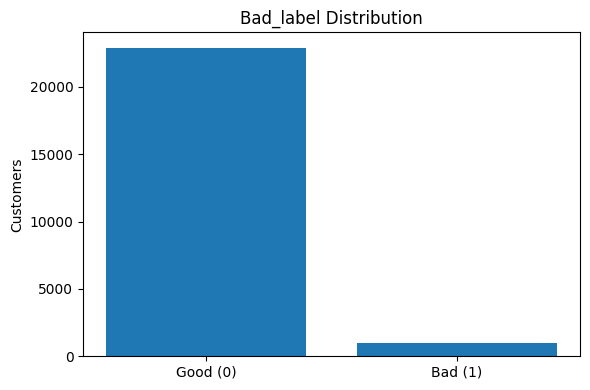

In [12]:
target_counts = demo_work["Bad_label"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["Good (0)","Bad (1)"], target_counts.values)
plt.title("Bad_label Distribution")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A bar chart is appropriate because `Bad_label` is a binary target. It provides a direct visual comparison of Good and Bad customers and helps identify class imbalance before model building.

##### 2. What is/are the insight(s) found from the chart?
The current dataset is strongly imbalanced: Good-credit customers form the clear majority and Bad-credit customers are the minority class. Therefore, a model could appear accurate simply by favouring the majority class. This is why the project cannot rely on Accuracy alone.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The imbalance finding supports class-aware baseline models and makes ROC-AUC, Gini and rank ordering more appropriate primary measures for this credit-risk ranking problem.


#### Chart - 2
**Top Missing Variables**

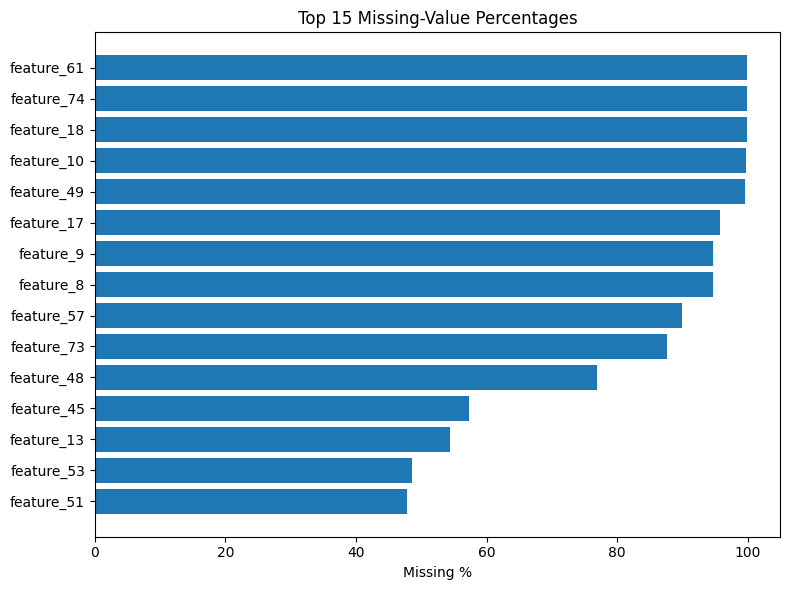

In [13]:
top_missing = missing_all[missing_all["Missing_Count"] > 0].head(15).sort_values("Missing_Pct")
plt.figure(figsize=(8,6))
plt.barh(top_missing["Column"], top_missing["Missing_Pct"])
plt.title("Top 15 Missing-Value Percentages")
plt.xlabel("Missing %")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A horizontal bar chart makes it easy to compare missing-value percentages across many variables while keeping the feature names readable.

##### 2. What is/are the insight(s) found from the chart?
The current data contains different levels of missingness across account, payment, enquiry and application fields. Missingness is therefore a data characteristic that must be handled carefully rather than causing automatic row deletion.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Training-only imputation and missing indicators make the scoring pipeline more robust when customer histories are incomplete and prevent information from the validation/test sets leaking into preprocessing.


#### Chart - 3
**Total Balance by Credit Label**

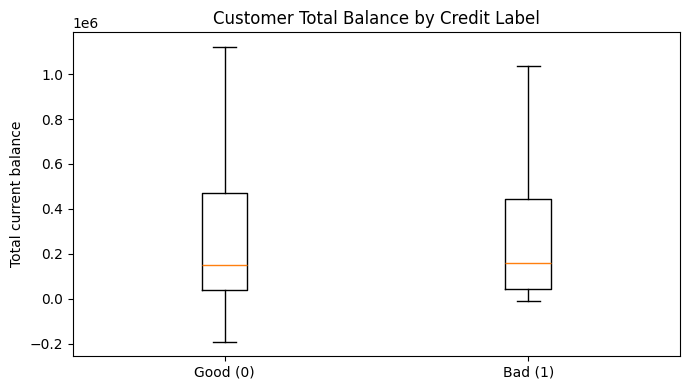

In [14]:
acct_eda = acct_raw.copy()
acct_eda["cur_balance_amt"] = pd.to_numeric(acct_eda["cur_balance_amt"], errors="coerce")
balance_customer = acct_eda.groupby("customer_no")["cur_balance_amt"].sum(min_count=1).rename("total_balance")
tmp = demo_work[["customer_no","Bad_label"]].merge(balance_customer, on="customer_no", how="left").fillna({"total_balance":0})
plt.figure(figsize=(7,4))
plt.boxplot([
    tmp.loc[tmp.Bad_label==0,"total_balance"],
    tmp.loc[tmp.Bad_label==1,"total_balance"]
], labels=["Good (0)","Bad (1)"], showfliers=False)
plt.title("Customer Total Balance by Credit Label")
plt.ylabel("Total current balance")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A box plot is useful for total current balance because financial amounts can be skewed and can contain extreme values. The plot compares the distribution, median and spread between Good and Bad customers.

##### 2. What is/are the insight(s) found from the chart?
The two target groups overlap substantially and the balance variable has a long-tailed distribution. Therefore, total balance alone is not sufficient to separate risk. The project uses balance together with credit limit, utilization, payment history and other behavioural variables.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The finding supports log-transformed monetary variables and ratios that represent relative exposure more robustly than raw amounts alone.


#### Chart - 4
**Past Due Amount by Credit Label**

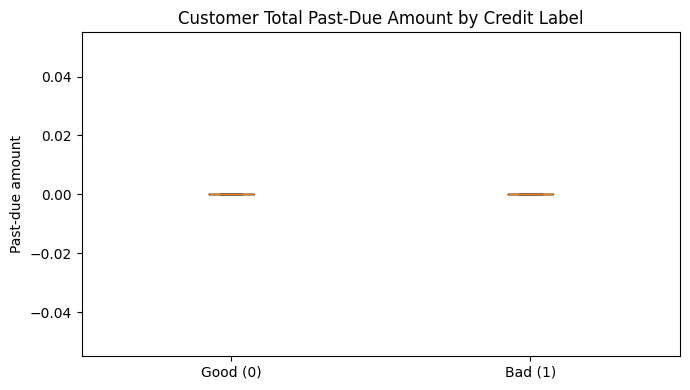

In [15]:
acct_eda["amt_past_due"] = pd.to_numeric(acct_eda["amt_past_due"], errors="coerce")
past_due_customer = acct_eda.groupby("customer_no")["amt_past_due"].sum(min_count=1).rename("total_past_due")
tmp = demo_work[["customer_no","Bad_label"]].merge(past_due_customer, on="customer_no", how="left").fillna({"total_past_due":0})
plt.figure(figsize=(7,4))
plt.boxplot([
    tmp.loc[tmp.Bad_label==0,"total_past_due"],
    tmp.loc[tmp.Bad_label==1,"total_past_due"]
], labels=["Good (0)","Bad (1)"], showfliers=False)
plt.title("Customer Total Past-Due Amount by Credit Label")
plt.ylabel("Past-due amount")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Past-due amount is directly related to delinquency, so its distribution by `Bad_label` is important in a credit-risk project.

##### 2. What is/are the insight(s) found from the chart?
The current distribution is concentrated around zero with a long tail of larger values. This means a raw mean can hide important delinquency behaviour. Presence, severity and aggregated past-due exposure are more useful modelling signals.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The result supports past-due indicators and severity aggregates that can help the model distinguish ordinary credit exposure from explicit delinquency behaviour.


#### Chart - 5
**Bad Rate by Credit Utilization Band**

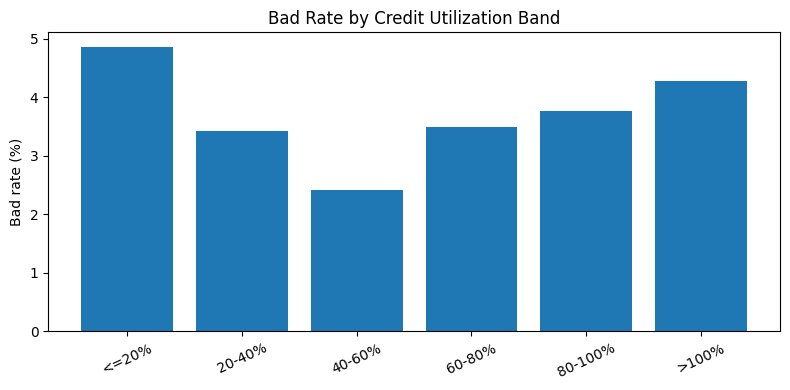

In [16]:
credit_customer = acct_eda.groupby("customer_no")["creditlimit"].sum(min_count=1).rename("credit_limit")
util_df = demo_work[["customer_no","Bad_label"]].merge(balance_customer, on="customer_no", how="left").merge(credit_customer, on="customer_no", how="left").fillna(0)
util_df["utilization"] = util_df["total_balance"] / util_df["credit_limit"].replace(0,np.nan)
util_df["utilization"] = util_df["utilization"].replace([np.inf,-np.inf],np.nan).fillna(0)
util_df["util_bin"] = pd.cut(
    util_df["utilization"],
    [-np.inf,0.2,0.4,0.6,0.8,1.0,np.inf],
    labels=["<=20%","20-40%","40-60%","60-80%","80-100%",">100%"]
)
bad_rate_util = util_df.groupby("util_bin", observed=False)["Bad_label"].mean()*100
plt.figure(figsize=(8,4))
plt.bar(bad_rate_util.index.astype(str), bad_rate_util.values)
plt.title("Bad Rate by Credit Utilization Band")
plt.ylabel("Bad rate (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A bad-rate-by-utilization chart checks whether observed credit risk changes across levels of credit utilization, an important measure of relative credit exposure.

##### 2. What is/are the insight(s) found from the chart?
Bad rates vary across utilization bands and the relationship is not perfectly linear. The highest-utilization group is relatively elevated, while some middle bands are lower, showing that utilization should be treated as a nonlinear behavioural feature rather than a single fixed cutoff.

##### 3. Will the gained insights help creating a positive business impact?
Yes. It supports utilization ratios, bands and nonlinear tree-based models that can capture interactions between utilization and other credit behaviours.


#### Chart - 6
**Account Count by Credit Label**

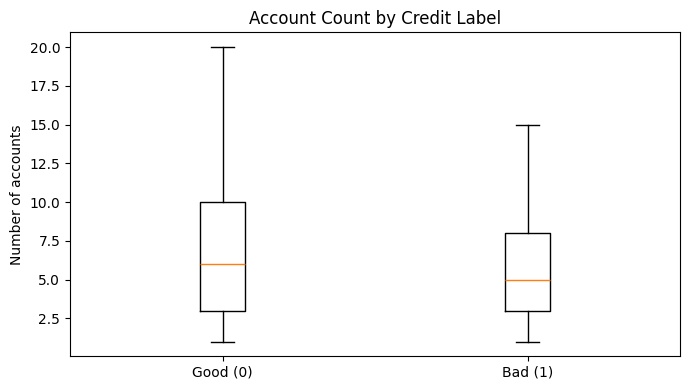

In [17]:
account_counts = acct_raw.groupby("customer_no").size().rename("account_count")
tmp = demo_work[["customer_no","Bad_label"]].merge(account_counts, on="customer_no", how="left").fillna({"account_count":0})
plt.figure(figsize=(7,4))
plt.boxplot([
    tmp.loc[tmp.Bad_label==0,"account_count"],
    tmp.loc[tmp.Bad_label==1,"account_count"]
], labels=["Good (0)","Bad (1)"], showfliers=False)
plt.title("Account Count by Credit Label")
plt.ylabel("Number of accounts")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A box plot compares the number of historical accounts held by Good and Bad customers and shows the distribution without being dominated by individual extreme customers.

##### 2. What is/are the insight(s) found from the chart?
The account-count distributions overlap considerably. Thus, the total number of accounts alone is not a strong risk discriminator. More useful information comes from account status, balances, limits and delinquency features.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The finding supports customer-level account aggregation and richer account-activity features instead of using a single account count as a decision rule.


#### Chart - 7
**Enquiry Count by Credit Label**

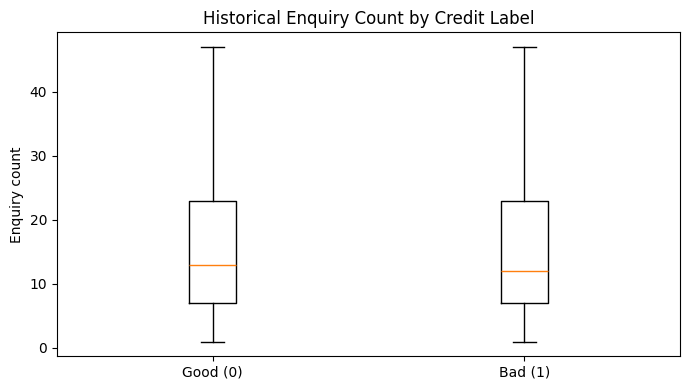

In [18]:
enquiry_counts = enq_raw.groupby("customer_no").size().rename("enquiry_count")
tmp = demo_work[["customer_no","Bad_label"]].merge(enquiry_counts, on="customer_no", how="left").fillna({"enquiry_count":0})
plt.figure(figsize=(7,4))
plt.boxplot([
    tmp.loc[tmp.Bad_label==0,"enquiry_count"],
    tmp.loc[tmp.Bad_label==1,"enquiry_count"]
], labels=["Good (0)","Bad (1)"], showfliers=False)
plt.title("Historical Enquiry Count by Credit Label")
plt.ylabel("Enquiry count")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A box plot is appropriate for historical enquiry count because it is a count variable that can be skewed. It helps compare the central tendency and spread between Good and Bad customers.

##### 2. What is/are the insight(s) found from the chart?
The Good and Bad groups show substantial overlap in total historical enquiry count. Their central tendency is close, so total enquiry count by itself is not a strong standalone discriminator. This is why the model also creates enquiry recency, amount and purpose-related features.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The insight supports using enquiry frequency as one part of a broader customer profile and gives justification for recency-based and purpose-level enquiry features.


#### Chart - 8
**Total Enquiry Amount by Credit Label**

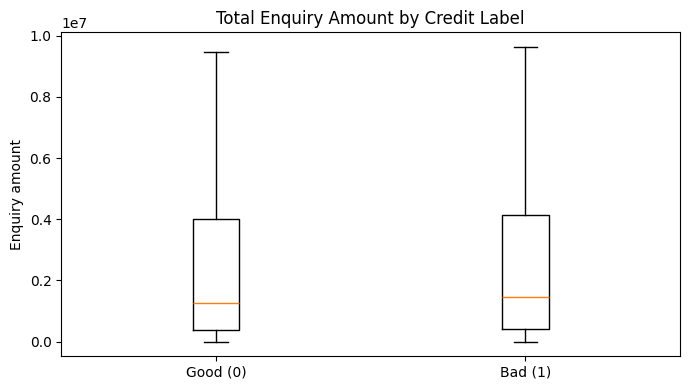

In [19]:
enq_eda = enq_raw.copy()
enq_eda["enq_amt"] = pd.to_numeric(enq_eda["enq_amt"], errors="coerce")
enq_amt_customer = enq_eda.groupby("customer_no")["enq_amt"].sum(min_count=1).rename("total_enquiry_amt")
tmp = demo_work[["customer_no","Bad_label"]].merge(enq_amt_customer, on="customer_no", how="left").fillna({"total_enquiry_amt":0})
plt.figure(figsize=(7,4))
plt.boxplot([
    tmp.loc[tmp.Bad_label==0,"total_enquiry_amt"],
    tmp.loc[tmp.Bad_label==1,"total_enquiry_amt"]
], labels=["Good (0)","Bad (1)"], showfliers=False)
plt.title("Total Enquiry Amount by Credit Label")
plt.ylabel("Enquiry amount")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Total enquiry amount is a monetary variable and can be strongly skewed. A box plot allows comparison of its distribution across the two target classes.

##### 2. What is/are the insight(s) found from the chart?
The Bad class shows a somewhat higher central tendency in total enquiry amount, while both groups have long-tailed distributions. This suggests useful signal may exist in enquiry amount, but it should be combined with recency and purpose features rather than used alone.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Log-transformed enquiry amount and customer-level amount aggregates can help represent credit-demand intensity while reducing the influence of extreme values.


#### Chart - 9
**Historical Enquiry Recency**

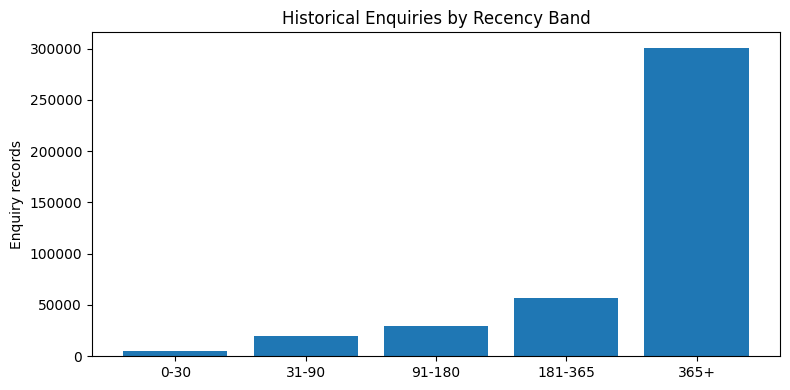

In [20]:
enq_tmp = enq_raw.copy()
enq_tmp["enquiry_dt_dt"] = parse_date_series(enq_tmp["enquiry_dt"])
enq_tmp["application_dt"] = enq_tmp["customer_no"].map(application_map)
enq_tmp = enq_tmp[
    enq_tmp["enquiry_dt_dt"].notna() &
    enq_tmp["application_dt"].notna() &
    (enq_tmp["enquiry_dt_dt"] <= enq_tmp["application_dt"])
].copy()
enq_tmp["days_before_app"] = (enq_tmp["application_dt"] - enq_tmp["enquiry_dt_dt"]).dt.days
enq_tmp["recency_band"] = pd.cut(
    enq_tmp["days_before_app"],
    [0,30,90,180,365,np.inf],
    labels=["0-30","31-90","91-180","181-365","365+"],
    include_lowest=True
)
counts = enq_tmp.groupby("recency_band", observed=False).size()
plt.figure(figsize=(8,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Historical Enquiries by Recency Band")
plt.ylabel("Enquiry records")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
This chart measures how recently historical credit enquiries occurred relative to the customer's application/opening date. Recency can contain information that is lost when using only a total enquiry count.

##### 2. What is/are the insight(s) found from the chart?
Most enquiry records in the current data are in the older-than-one-year band, while the shorter recency windows contain fewer records. This supports creating separate 30-, 90-, 180- and 365-day enquiry features.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Recency features allow the model to distinguish long-standing historical activity from more recent credit-seeking behaviour and align with the project's suggested enquiry-recency features.


#### Chart - 10
**Payment History Status Summary**

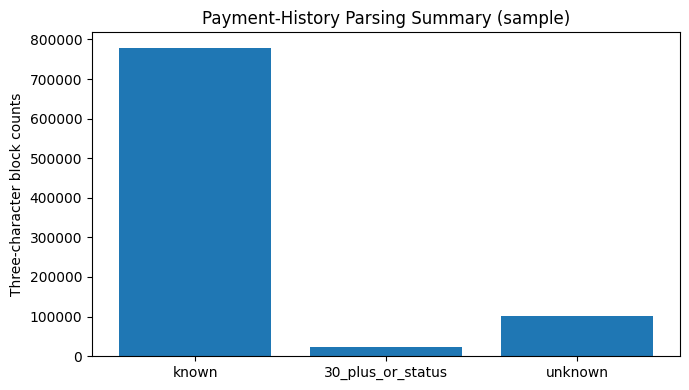

In [21]:
def payment_status_counts(row):
    def clean(v):
        return "" if pd.isna(v) else str(v).strip().strip('"').strip("'")
    full = clean(row["paymenthistory1"]) + clean(row["paymenthistory2"])
    toks = [full[i:i+3] for i in range(0,len(full),3) if len(full[i:i+3])==3]
    known = severe = unknown = 0
    for t in toks:
        if t == "XXX":
            unknown += 1
        elif t == "STD":
            known += 1
        elif t.isdigit():
            known += 1
            if int(t) >= 30: severe += 1
        elif t in {"SMA","SUB","DBT","LSS"}:
            known += 1
            severe += 1
        else:
            unknown += 1
    return pd.Series({"known":known,"30_plus_or_status":severe,"unknown":unknown})

ph = acct_raw[["paymenthistory1","paymenthistory2"]].head(min(50000,len(acct_raw)))
ph_counts = ph.apply(payment_status_counts, axis=1).sum()
plt.figure(figsize=(7,4))
plt.bar(ph_counts.index, ph_counts.values)
plt.title("Payment-History Parsing Summary (sample)")
plt.ylabel("Three-character block counts")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Payment history is stored as structured three-character status blocks rather than free-form text. This visualization is used to validate the parsing logic before creating delinquency features.

##### 2. What is/are the insight(s) found from the chart?
The raw history contains standard/status values, numeric DPD values and unknown blocks such as `XXX`. The important data-preparation decision is that `XXX` is treated as unknown/missing and not incorrectly converted to 0 DPD.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Correct payment-history parsing allows the model to use 30+, 60+ and 90+ DPD measures without confusing unavailable information with good repayment behaviour.


#### Chart - 11
**Account Type Distribution**

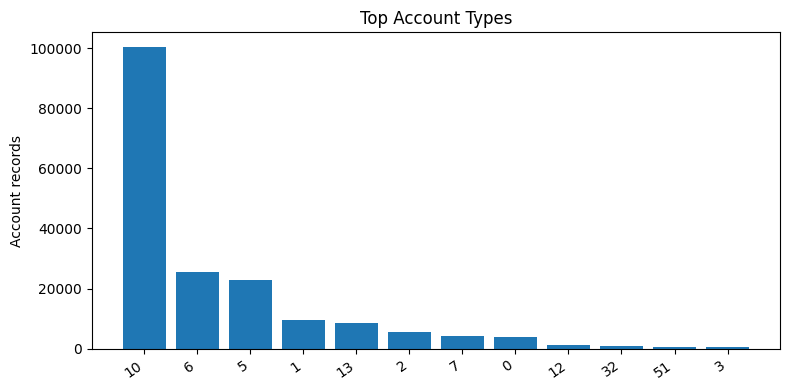

In [22]:
account_type_counts = acct_raw["acct_type"].value_counts().head(12)
plt.figure(figsize=(8,4))
plt.bar(account_type_counts.index.astype(str), account_type_counts.values)
plt.title("Top Account Types")
plt.ylabel("Account records")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A bar chart shows the frequency of account-type codes and helps understand the composition of customers' historical credit accounts.

##### 2. What is/are the insight(s) found from the chart?
Several account-type codes dominate the dataset while others are less frequent. These are categorical identifiers, not ordered numeric measurements, so treating the codes as continuous values would introduce an artificial relationship.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Customer-level account-type counts preserve account-composition information without assuming that a larger category code means a larger or better financial value.


#### Chart - 12
**Enquiry Purpose Distribution**

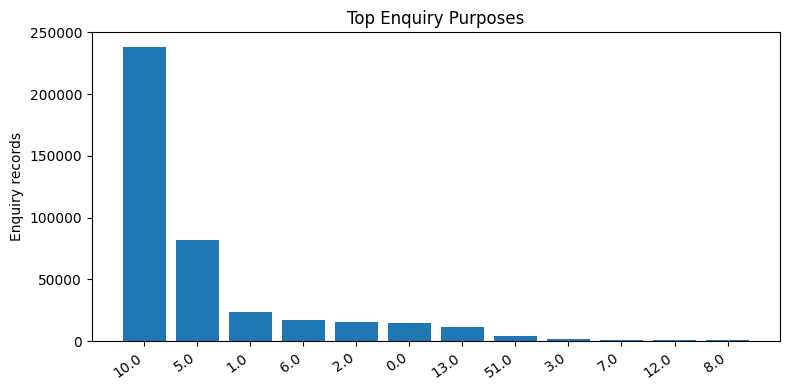

In [23]:
purpose_counts = enq_raw["enq_purpose"].value_counts().head(12)
plt.figure(figsize=(8,4))
plt.bar(purpose_counts.index.astype(str), purpose_counts.values)
plt.title("Top Enquiry Purposes")
plt.ylabel("Enquiry records")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A bar chart is useful for showing which enquiry-purpose codes are common and which are relatively rare.

##### 2. What is/are the insight(s) found from the chart?
The enquiry-purpose distribution is concentrated in several categories. Because the source data intentionally provides coded/encrypted categories without business descriptions, the project keeps their statistical identity but does not invent semantic labels for them.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Purpose counts and purpose diversity can add predictive information beyond total enquiry volume while respecting the anonymized coding of the source data.


#### Chart - 13
**Utilization Distribution by Target**

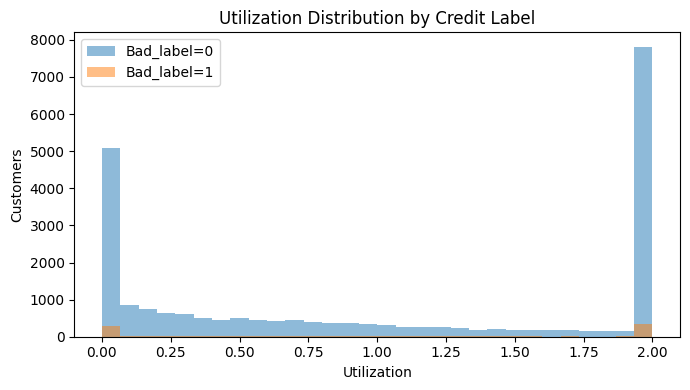

In [24]:
plt.figure(figsize=(7,4))
for label in [0,1]:
    vals = util_df.loc[util_df.Bad_label==label,"utilization"].clip(0,2)
    plt.hist(vals, bins=30, alpha=0.5, label=f"Bad_label={label}")
plt.title("Utilization Distribution by Credit Label")
plt.xlabel("Utilization")
plt.ylabel("Customers")
plt.legend()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A histogram complements the utilization-band chart by showing the complete distribution and the amount of overlap between Good and Bad customers.

##### 2. What is/are the insight(s) found from the chart?
The two target classes overlap, but the distributions have different spread and tail behaviour. This indicates that utilization is not best represented by a single linear effect.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The observation supports utilization ratios, transformations and nonlinear models that can learn interactions with other credit-risk variables.


#### Chart - 14 - Correlation Heatmap
**Correlation Heatmap**

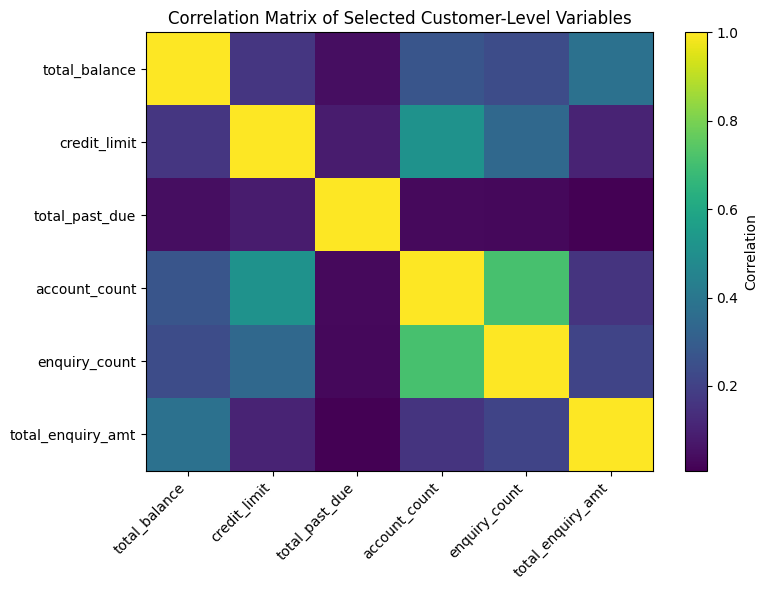

In [25]:
corr_base = pd.DataFrame({
    "total_balance": balance_customer,
    "credit_limit": credit_customer,
    "total_past_due": past_due_customer,
    "account_count": account_counts,
    "enquiry_count": enquiry_counts,
    "total_enquiry_amt": enq_amt_customer
}).fillna(0)

corr = corr_base.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr.values, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Selected Customer-Level Variables")
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A correlation heatmap provides a compact view of linear relationships among important customer-level aggregates and helps identify potentially redundant variables.

##### 2. What is/are the insight(s) found from the chart?
The selected aggregates show some moderate relationships—for example, customer balance and total enquiry amount are related—but no near-perfect correlation dominates these variables. This indicates that the features contain some shared information while still offering distinct signals.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The heatmap supports a redundancy check and helps guide feature engineering. It is not used as the only feature-selection method because useful nonlinear relationships may not appear as high Pearson correlation.


#### Chart - 15 - Pair Plot
**Pair Plot**

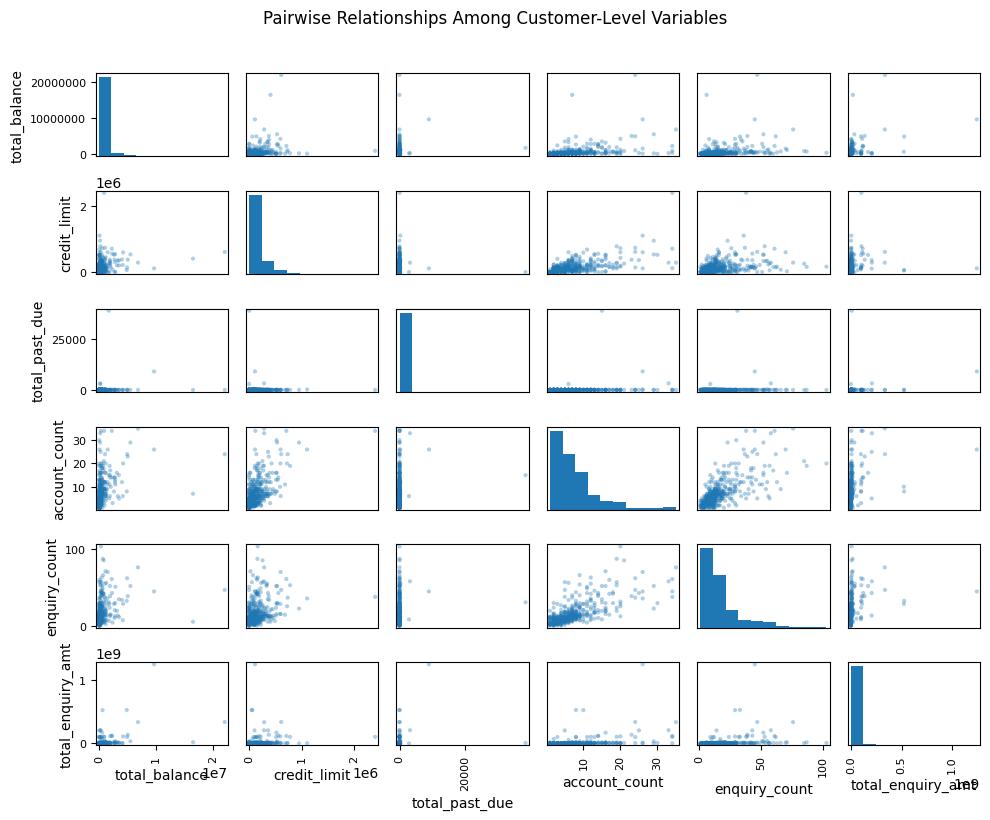

In [26]:
from pandas.plotting import scatter_matrix
pair_sample = corr_base.sample(min(400,len(corr_base)), random_state=RANDOM_STATE)
scatter_matrix(pair_sample, figsize=(10,8), diagonal="hist", alpha=0.35)
plt.suptitle("Pairwise Relationships Among Customer-Level Variables", y=1.02)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A scatter-matrix gives a compact multivariate view of several important customer-level variables. A manageable sample is used so that the chart remains readable.

##### 2. What is/are the insight(s) found from the chart?
The pairwise plots show skewed monetary/count variables and substantial overlap between customer groups. This reinforces the need for transformed ratios and nonlinear models rather than assuming simple linear separation.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The visualization supports combining behavioural features and using tree-based models that can capture interactions not visible from one variable at a time.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusions about the selected relationships.

The hypotheses focus on relationships that are relevant to credit-risk behaviour. The statistical significance level is alpha = 0.05. The code cells calculate the p-values from the current dataset and print the decision and interpretation.


### Hypothetical Statement - 1

**H0:** Good and Bad customers have the same distribution of total current balance.

**H1:** Good and Bad customers have different distributions of total current balance.

This test checks whether overall customer balance exposure differs statistically between the two target classes.


In [27]:
h1 = demo_work[["customer_no","Bad_label"]].merge(balance_customer,on="customer_no",how="left").fillna({"total_balance":0})
good = h1.loc[h1.Bad_label==0,"total_balance"]
bad = h1.loc[h1.Bad_label==1,"total_balance"]
u1,p1 = mannwhitneyu(good,bad,alternative="two-sided")
print(f"Mann-Whitney U statistic: {u1:.4f}")
print(f"P-value: {p1:.6g}")
print("Decision at alpha=0.05:", "Reject H0" if p1<0.05 else "Fail to reject H0")

alpha=0.05
print(
    "Interpretation:",
    "Reject H0 — the Good and Bad groups have statistically different total-balance distributions."
    if p1 < alpha else
    "Fail to reject H0 — the current data does not provide sufficient evidence that total-balance distributions differ between Good and Bad groups."
)


Mann-Whitney U statistic: 11472208.5000
P-value: 0.927097
Decision at alpha=0.05: Fail to reject H0
Interpretation: Fail to reject H0 — the current data does not provide sufficient evidence that total-balance distributions differ between Good and Bad groups.


##### Which statistical test have you done to obtain P-Value?

**Mann-Whitney U test.**

It compares the two independent groups without assuming that total balance follows a normal distribution.


##### Why did you choose the specific statistical test?

Total balance is a continuous financial variable with strong skew and potential outliers. Mann-Whitney U is a non-parametric alternative that compares the distributions/ranks of two independent groups without requiring normality.


### Hypothetical Statement - 2

**H0:** Good and Bad customers have the same distribution of historical enquiry counts.

**H1:** Good and Bad customers have different distributions of historical enquiry counts.

This tests whether historical enquiry activity differs statistically between the two target classes.


In [28]:
h2 = demo_work[["customer_no","Bad_label"]].merge(enquiry_counts,on="customer_no",how="left").fillna({"enquiry_count":0})
good = h2.loc[h2.Bad_label==0,"enquiry_count"]
bad = h2.loc[h2.Bad_label==1,"enquiry_count"]
u2,p2 = mannwhitneyu(good,bad,alternative="two-sided")
print(f"Mann-Whitney U statistic: {u2:.4f}")
print(f"P-value: {p2:.6g}")
print("Decision at alpha=0.05:", "Reject H0" if p2<0.05 else "Fail to reject H0")

alpha=0.05
print(
    "Interpretation:",
    "Reject H0 — the Good and Bad groups have statistically different enquiry-count distributions."
    if p2 < alpha else
    "Fail to reject H0 — the current data does not provide sufficient evidence that enquiry-count distributions differ between Good and Bad groups."
)


Mann-Whitney U statistic: 11668238.5000
P-value: 0.409225
Decision at alpha=0.05: Fail to reject H0
Interpretation: Fail to reject H0 — the current data does not provide sufficient evidence that enquiry-count distributions differ between Good and Bad groups.


##### Which statistical test have you done to obtain P-Value?

**Mann-Whitney U test.**

It is appropriate for a discrete count variable that may be skewed and does not require a normal distribution.


##### Why did you choose the specific statistical test?

Historical enquiry count is a discrete, potentially skewed count variable. Mann-Whitney U is suitable for comparing the two independent target groups without assuming a normal distribution.


### Hypothetical Statement - 3

**H0:** Presence of 30+ DPD payment-history behaviour is independent of `Bad_label`.

**H1:** Presence of 30+ DPD payment-history behaviour is associated with `Bad_label`.

This tests whether a specific delinquency-history indicator is statistically associated with the observed bad-credit outcome.


In [29]:
def has_30_plus_from_history(a,b):
    def clean(v):
        return "" if pd.isna(v) else str(v).strip().strip('"').strip("'")
    full = clean(a)+clean(b)
    toks = [full[i:i+3] for i in range(0,len(full),3) if len(full[i:i+3])==3]
    return int(any(
        (t.isdigit() and int(t)>=30) or t in {"SMA","SUB","DBT","LSS"}
        for t in toks
    ))

ph_flag = acct_raw[["customer_no","paymenthistory1","paymenthistory2"]].copy()
ph_flag["has_30_plus"] = [
    has_30_plus_from_history(a,b)
    for a,b in zip(ph_flag["paymenthistory1"],ph_flag["paymenthistory2"])
]
ph_cust = ph_flag.groupby("customer_no")["has_30_plus"].max().rename("has_30_plus")

h3 = demo_work[["customer_no","Bad_label"]].merge(
    ph_cust,on="customer_no",how="left"
).fillna({"has_30_plus":0})

cont = pd.crosstab(h3["has_30_plus"],h3["Bad_label"])
chi2,p3,dof,expected = chi2_contingency(cont)

display(cont)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p3:.6g}")
print("Decision at alpha=0.05:", "Reject H0" if p3<0.05 else "Fail to reject H0")
print(
    "Interpretation:",
    "Reject H0 — the presence of 30+ DPD payment-history behaviour is significantly associated with Bad_label."
    if p3 < 0.05 else
    "Fail to reject H0 — the current data does not provide sufficient evidence of an association between 30+ DPD payment-history behaviour and Bad_label."
)


Bad_label,0,1
has_30_plus,,
0,17202,711
1,5690,293


Chi-square statistic: 9.3673
P-value: 0.00220886
Decision at alpha=0.05: Reject H0
Interpretation: Reject H0 — the presence of 30+ DPD payment-history behaviour is significantly associated with Bad_label.


##### Which statistical test have you done to obtain P-Value?

**Chi-square test of independence.**

It evaluates whether two categorical variables—30+ DPD presence and `Bad_label`—are statistically independent.


##### Why did you choose the specific statistical test?

Both variables are categorical/binary. A chi-square test of independence is designed to compare observed and expected frequencies in a contingency table and determine whether the two categorical variables are associated.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [30]:
display(missing_all[missing_all.Missing_Count>0].head(20).round(2))


,Column,Missing_Count,Missing_Pct,Dataset
0,feature_61,23887,99.96,Demographics
1,feature_74,23879,99.93,Demographics
2,feature_18,23878,99.92,Demographics
3,feature_10,23845,99.79,Demographics
4,feature_49,23792,99.56,Demographics
5,feature_17,22869,95.70,Demographics
6,feature_8,22635,94.72,Demographics
7,feature_9,22635,94.72,Demographics
8,feature_57,21503,89.99,Demographics
9,feature_73,20951,87.68,Demographics


#### What all missing value imputation techniques have you used and why did you use those techniques?

Numeric modelling variables are imputed with the **training-set median** because financial and count features can be skewed and the median is robust to extreme values.

Non-numeric/coded fields are converted using **training-derived frequency encoding**, with missing indicators where appropriate.

The validation and test sets only receive transformations learned from training data, preventing leakage during preprocessing.


### 2. Handling Outliers

In [31]:
outlier_cols=["cur_balance_amt","creditlimit","amt_past_due","high_credit_amt","actualpaymentamount"]
rows=[]
for c in outlier_cols:
    s=pd.to_numeric(acct_raw[c],errors="coerce")
    rows.append({"Feature":c,"P95":s.quantile(.95),"P99":s.quantile(.99),"Max":s.max()})
display(pd.DataFrame(rows).round(2))


,Feature,P95,P99,Max
0,cur_balance_amt,279299.8,1465971.44,136009965.0
1,creditlimit,194000.0,348000.00,2500000.0
2,amt_past_due,63338.0,305409.75,4869309.0
3,high_credit_amt,550000.0,2340000.00,180000000.0
4,actualpaymentamount,85001.2,370000.00,67853221.0


##### What all outlier treatment techniques have you used and why did you use those techniques?

We do not blindly remove extreme financial observations because high balances or limits can be genuine customer behaviour.

Instead, we inspect P95/P99/max values, create `log1p` versions of skewed monetary aggregates, use relative ratios such as utilization, and rely on tree-based models to capture nonlinear effects without requiring arbitrary deletion of valid customers.


### 3. Categorical Encoding

Account type, ownership, payment frequency and enquiry-purpose values are treated as categorical codes rather than ordered numeric values.

For the final modelling matrix, non-numeric fields use **training-only frequency encoding**. This avoids an artificial ordinal relationship and keeps the feature space compact.


### 4. Textual Data Preprocessing

Natural-language preprocessing is not required. The payment-history variables are structured three-character financial-status blocks.

They are parsed into delinquency-related numerical features, while unknown blocks such as `XXX` are preserved as unknown/missing rather than being interpreted as zero DPD.


### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [32]:
# Build account-level payment-history and financial features.
def parse_payment_history(s1,s2):
    def clean(v): return "" if pd.isna(v) else str(v).strip().strip('"').strip("'")
    full=clean(s1)+clean(s2)
    toks=[full[i:i+3] for i in range(0,len(full),3) if len(full[i:i+3])==3]
    vals=[]
    for t in toks:
        if t=="XXX": vals.append(np.nan)
        elif t=="STD": vals.append(0.0)
        elif t=="SMA": vals.append(30.0)
        elif t in {"SUB","DBT","LSS"}: vals.append(90.0)
        elif t.isdigit(): vals.append(float(int(t)))
        else: vals.append(np.nan)
    a=np.asarray(vals,dtype=float); known=~np.isnan(a); over30=np.where((a>=30)&known)[0]
    return pd.Series({
        "ph_len":len(a),"ph_known_months":int(known.sum()),
        "ph_unknown_months":int((~known).sum()),
        "ph_0_29":int(((a<30)&known).sum()),
        "ph_30_plus":int(((a>=30)&known).sum()),
        "ph_60_plus":int(((a>=60)&known).sum()),
        "ph_90_plus":int(((a>=90)&known).sum()),
        "ph_min_months_30":int(over30[0]+1) if len(over30) else -1,
        "ph_max_dpd":float(np.nanmax(a)) if known.any() else np.nan,
        "ph_avg_dpd":float(np.nanmean(a)) if known.any() else np.nan
    })

acct=acct_raw.copy()
for c in ["dt_opened","upload_dt","opened_dt","last_paymt_dt","closed_dt","reporting_dt","paymt_str_dt","paymt_end_dt"]:
    acct[c+"_dt"]=parse_date_series(acct[c])
for c in ["high_credit_amt","cur_balance_amt","amt_past_due","creditlimit","cashlimit","rateofinterest","actualpaymentamount"]:
    acct[c]=pd.to_numeric(acct[c],errors="coerce")
acct["application_dt"]=acct["customer_no"].map(application_map)

acct=acct[
    ((acct["reporting_dt_dt"].isna()) | (acct["reporting_dt_dt"]<=acct["application_dt"])) &
    ((acct["opened_dt_dt"].isna()) | (acct["opened_dt_dt"]<=acct["application_dt"]))
].copy()

parsed=pd.DataFrame([parse_payment_history(a,b) for a,b in zip(acct["paymenthistory1"],acct["paymenthistory2"])],index=acct.index)
acct=acct.join(parsed)

acct["diff_lastpaymt_opened_dt"]=(acct["last_paymt_dt_dt"]-acct["opened_dt_dt"]).dt.days
acct["days_since_opened"]=(acct["application_dt"]-acct["opened_dt_dt"]).dt.days
acct["days_since_lastpay"]=(acct["application_dt"]-acct["last_paymt_dt_dt"]).dt.days
acct["is_closed"]=acct["closed_dt_dt"].notna().astype(int)
acct["is_active"]=(acct["closed_dt_dt"].isna() & ((acct["cur_balance_amt"].fillna(0)>0)|(acct["creditlimit"].fillna(0)>0))).astype(int)

g=acct.groupby("customer_no")
feat=g.size().to_frame("total_account_count")
account_aggs={
    "active_account_count":g["is_active"].sum(),
    "closed_account_count":g["is_closed"].sum(),
    "total_current_balance":g["cur_balance_amt"].sum(min_count=1),
    "mean_current_balance":g["cur_balance_amt"].mean(),
    "max_current_balance":g["cur_balance_amt"].max(),
    "total_credit_limit":g["creditlimit"].sum(min_count=1),
    "mean_credit_limit":g["creditlimit"].mean(),
    "max_credit_limit":g["creditlimit"].max(),
    "total_cash_limit":g["cashlimit"].sum(min_count=1),
    "mean_cash_limit":g["cashlimit"].mean(),
    "total_high_credit":g["high_credit_amt"].sum(min_count=1),
    "mean_high_credit":g["high_credit_amt"].mean(),
    "total_amount_past_due":g["amt_past_due"].sum(min_count=1),
    "max_amount_past_due":g["amt_past_due"].max(),
    "total_actual_payment":g["actualpaymentamount"].sum(min_count=1),
    "mean_actual_payment":g["actualpaymentamount"].mean(),
    "mean_rateofinterest":g["rateofinterest"].mean(),
    "max_rateofinterest":g["rateofinterest"].max(),
    "total_diff_lastpaymt_opened_dt":g["diff_lastpaymt_opened_dt"].sum(min_count=1),
    "mean_diff_lastpaymt_opened_dt":g["diff_lastpaymt_opened_dt"].mean(),
    "oldest_acct_days":g["days_since_opened"].max(),
    "newest_acct_days":g["days_since_opened"].min(),
    "recency_last_payment_days":g["days_since_lastpay"].min(),
    "payment_history_avg_dpd_0_29_bucket":g["ph_0_29"].mean(),
    "payment_history_mean_length":g["ph_len"].mean(),
    "payment_history_known_months":g["ph_known_months"].sum(),
    "payment_history_unknown_months":g["ph_unknown_months"].sum(),
    "min_months_last_30_plus":g["ph_min_months_30"].apply(lambda s:s[s>=0].min() if (s>=0).any() else -1),
    "total_30_plus_months":g["ph_30_plus"].sum(),
    "total_60_plus_months":g["ph_60_plus"].sum(),
    "total_90_plus_months":g["ph_90_plus"].sum(),
    "max_dpd_ever":g["ph_max_dpd"].max(),
    "avg_dpd_ever":g["ph_avg_dpd"].mean()
}
for name,series in account_aggs.items(): feat[name]=series
feat["active_acct_ratio"]=feat["active_account_count"]/feat["total_account_count"].replace(0,np.nan)
feat["has_past_due"]=(feat["total_amount_past_due"].fillna(0)>0).astype(int)
acct30=g["ph_30_plus"].sum().gt(0).astype(int)
feat["count_accts_with_30_plus"]=acct30
feat["ratio_accts_with_30_plus"]=acct30/feat["total_account_count"].replace(0,np.nan)
feat["Ratio_currbalance_creditlimit"]=feat["total_current_balance"]/feat["total_credit_limit"].replace(0,np.nan)
feat["Ratio_currbalance_highcredit"]=feat["total_current_balance"]/feat["total_high_credit"].replace(0,np.nan)
feat["utilisation_trend"]=feat["Ratio_currbalance_creditlimit"]/(
    feat["mean_current_balance"]/(feat["mean_credit_limit"]+feat["mean_cash_limit"]).replace(0,np.nan)
)

for col,prefix in [("acct_type","acct_type"),("owner_indic","owner_indic"),("paymentfrequency","paymentfrequency")]:
    ct=pd.crosstab(acct["customer_no"],acct[col])
    ct.columns=[f"{prefix}_{v}_count" for v in ct.columns]
    feat=feat.join(ct,how="left")

# Enquiry features.
enq=enq_raw.copy()
enq["dt_opened_dt"]=parse_date_series(enq["dt_opened"])
enq["enquiry_dt_dt"]=parse_date_series(enq["enquiry_dt"])
enq["application_dt"]=enq["customer_no"].map(application_map)
enq["enq_amt"]=pd.to_numeric(enq["enq_amt"],errors="coerce")
enq=enq[
    enq["enquiry_dt_dt"].notna() &
    enq["application_dt"].notna() &
    (enq["enquiry_dt_dt"]<=enq["application_dt"])
].copy()
enq["days_diff"]=(enq["application_dt"]-enq["enquiry_dt_dt"]).dt.days

eg=enq.groupby("customer_no")
enq_feat=eg.size().to_frame("total_enquiry_count")
for name,series in {
    "total_enquiry_amt":eg["enq_amt"].sum(min_count=1),
    "mean_enquiry_amt":eg["enq_amt"].mean(),
    "max_enquiry_amt":eg["enq_amt"].max(),
    "mean_diff_open_enquiry_dt":eg["days_diff"].mean(),
    "min_diff_open_enquiry_dt":eg["days_diff"].min(),
    "num_unique_enq_purp":eg["enq_purpose"].nunique()
}.items():
    enq_feat[name]=series

for d in [30,90,180,365]:
    enq_feat[f"count_enquiry_recency_{d}"]=enq.loc[enq["days_diff"]<=d].groupby("customer_no").size()

purpose_ct=pd.crosstab(enq["customer_no"],enq["enq_purpose"])
purpose_ct.columns=[f"enq_purpose_{v}_count" for v in purpose_ct.columns]
enq_feat=enq_feat.join(purpose_ct,how="left").fillna(0)
enq_feat["enq_velocity_90_365"]=enq_feat["count_enquiry_recency_90"]/(enq_feat["count_enquiry_recency_365"]+1)

full=demo_work.set_index("customer_no").join(feat).join(enq_feat).reset_index()
full["log_total_current_balance"]=np.log1p(full["total_current_balance"].clip(lower=0).fillna(0))
full["log_total_credit_limit"]=np.log1p(full["total_credit_limit"].clip(lower=0).fillna(0))
full["log_total_enquiry_amt"]=np.log1p(full["total_enquiry_amt"].clip(lower=0).fillna(0))
full["utilization_risk_flag"]=(full["Ratio_currbalance_creditlimit"].fillna(0)>0.8).astype(int)
full["severe_delinq_flag"]=(full["total_90_plus_months"].fillna(0)>0).astype(int)
full["has_enquiry_past_30d"]=(full["count_enquiry_recency_30"].fillna(0)>0).astype(int)

assert len(full)==full["customer_no"].nunique()==len(demo_raw)
print("Unified customer-level matrix:",full.shape)


Unified customer-level matrix: (23896, 220)


#### 2. Feature Selection

In [33]:
DROP=["customer_no","dt_opened","entry_time","application_dt","entry_time_dt","Bad_label"]
feature_cols=[c for c in full.columns if c not in DROP]
X_all=full[feature_cols].copy()
y_all=full["Bad_label"].astype(int)
ids=full["customer_no"].copy()

X_dev,X_test,y_dev,y_test,id_dev,id_test=train_test_split(
    X_all,y_all,ids,test_size=0.20,random_state=RANDOM_STATE,stratify=y_all
)
X_train,X_val,y_train,y_val,id_train,id_val=train_test_split(
    X_dev,y_dev,id_dev,test_size=0.20,random_state=RANDOM_STATE,stratify=y_dev
)

assert set(id_train).isdisjoint(id_val)
assert set(id_train).isdisjoint(id_test)
assert set(id_val).isdisjoint(id_test)

class TrainOnlyEncoder:
    def __init__(self,numeric_parse_rate=0.90): self.rate=numeric_parse_rate
    def fit(self,X):
        self.numeric=[]; self.categorical=[]; self.maps={}; self.medians={}
        for c in X.columns:
            if pd.api.types.is_numeric_dtype(X[c]):
                self.numeric.append(c); self.medians[c]=pd.to_numeric(X[c],errors="coerce").median()
            else:
                s=X[c].astype("string"); n=pd.to_numeric(s,errors="coerce")
                if n.notna().mean()>=self.rate:
                    self.numeric.append(c); self.medians[c]=n.median()
                else:
                    self.categorical.append(c)
                    self.maps[c]=s.fillna("__MISSING__").value_counts(normalize=True).to_dict()
        return self
    def transform(self,X):
        out=pd.DataFrame(index=X.index)
        for c in self.numeric:
            out[c]=pd.to_numeric(X[c],errors="coerce").fillna(self.medians[c])
        for c in self.categorical:
            s=X[c].astype("string")
            out[c]=s.fillna("__MISSING__").map(self.maps[c]).fillna(0.0)
            out[c+"__missing"]=X[c].isna().astype(int)
        return out.astype(float)

enc=TrainOnlyEncoder().fit(X_train)
Xtr_enc=enc.transform(X_train)
Xv_enc=enc.transform(X_val)
Xte_enc=enc.transform(X_test)

all_empty=[c for c in Xtr_enc.columns if Xtr_enc[c].isna().all()]
if all_empty:
    Xtr_enc=Xtr_enc.drop(columns=all_empty)
    Xv_enc=Xv_enc.drop(columns=all_empty)
    Xte_enc=Xte_enc.drop(columns=all_empty)

imp=SimpleImputer(strategy="median")
Xtr=pd.DataFrame(imp.fit_transform(Xtr_enc),columns=Xtr_enc.columns,index=Xtr_enc.index)
Xv=pd.DataFrame(imp.transform(Xv_enc),columns=Xtr_enc.columns,index=Xv_enc.index)
Xte=pd.DataFrame(imp.transform(Xte_enc),columns=Xtr_enc.columns,index=Xte_enc.index)

cat_sel=CatBoostClassifier(iterations=180,learning_rate=0.04,depth=5,l2_leaf_reg=5,random_seed=RANDOM_STATE,verbose=0,thread_count=1)
cat_sel.fit(Xtr,y_train)
cat_imp=pd.Series(cat_sel.get_feature_importance(),index=Xtr.columns)

xgb_sel=XGBClassifier(n_estimators=160,learning_rate=0.03,max_depth=4,min_child_weight=10,
                      subsample=0.8,colsample_bytree=0.8,reg_lambda=2,
                      eval_metric="logloss",random_state=RANDOM_STATE,n_jobs=1)
xgb_sel.fit(Xtr,y_train)
raw_gain=xgb_sel.get_booster().get_score(importance_type="gain")
xgb_gain=pd.Series({c:float(raw_gain.get(c,0.0)) for c in Xtr.columns})

cat_norm=cat_imp/(cat_imp.sum() or 1)
xgb_norm=xgb_gain/(xgb_gain.sum() or 1)
blended=(0.5*cat_norm+0.5*xgb_norm).sort_values(ascending=False)

SELECTED_FEATURE_COUNT=66
selected_features=blended.head(min(SELECTED_FEATURE_COUNT,len(blended))).index.tolist()
Xtr66=Xtr[selected_features]
Xv66=Xv[selected_features]
Xte66=Xte[selected_features]

print("Selected features:",len(selected_features))


Selected features: 66


##### What all feature selection methods have you used and why?

Training-only CatBoost and XGBoost importance/gain are blended 50/50 to select up to 66 features, matching the supplied benchmark configuration.

##### Which all features you found important and why?

The final feature matrix below reports the actual training-derived ranking. Candidate families include payment history, credit utilization, account activity, enquiry recency and anonymized demographic/application attributes.

### 3. Data Splitting

The split is 80% development and 20% untouched test, followed by an 80/20 train-validation split inside development.

##### What data splitting ratio have you used and why?
The untouched 20% holdout is reserved for the final performance estimate.

### 4. Handling Imbalanced Dataset

In [34]:
target_summary=y_all.value_counts().sort_index().to_frame("Customers")
target_summary["Percentage"]=target_summary["Customers"]/len(y_all)*100
display(target_summary.round(3))


,Customers,Percentage
Bad_label,,
0,22892,95.798
1,1004,4.202


##### Do you think the dataset is imbalanced? Explain Why.
The actual class percentages are shown above. Model selection is driven by ranking metrics rather than raw accuracy.

##### What technique did you use to handle the imbalance dataset and why?
Class weighting is used for Logistic Regression, Decision Tree and Random Forest baselines. SMOTE is not automatically applied because probability ranking is the main objective.

## ***7. ML Model Implementation***

### ML Model - 1

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Model used: Logistic Regression**

Logistic Regression is the interpretable baseline. It estimates the probability that a customer belongs to `Bad_label = 1`. It is fitted on the selected 66 features after leakage-safe preprocessing.

`StandardScaler` is used because Logistic Regression is sensitive to feature scale, and `class_weight="balanced"` gives the minority Bad class more influence during training.

The evaluation table and score chart below are generated from the actual validation predictions. For this project, ROC-AUC and Gini are the main discrimination measures; Precision, Recall, F1 and Accuracy are secondary threshold-based measures.


,ROC-AUC,Gini,PR-AUC,KS,Precision,Recall,F1,Accuracy,Threshold
Logistic Regression,0.6694,0.3389,0.0879,0.2782,0.087,0.5155,0.1489,0.7518,0.5795


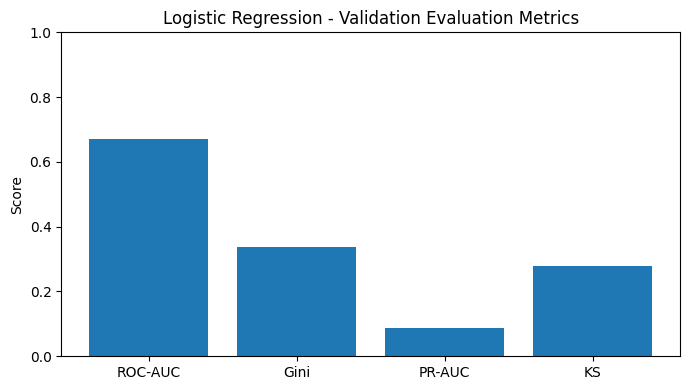

In [35]:
def gini(auc):
    """Convert ROC-AUC to the Gini coefficient used in the project."""
    return 2.0 * float(auc) - 1.0

def best_f1_threshold(y, p):
    """Select a threshold on validation data for secondary classification metrics."""
    pr, re, th = precision_recall_curve(y, p)
    if len(th) == 0:
        return 0.5
    f1 = 2 * pr[:-1] * re[:-1] / (pr[:-1] + re[:-1] + 1e-12)
    return float(th[int(np.nanargmax(f1))])

def evaluate_predictions(y, p, threshold=None):
    if threshold is None:
        threshold = best_f1_threshold(y, p)
    pred = (p >= threshold).astype(int)
    auc = roc_auc_score(y, p)

    return {
        "ROC-AUC": auc,
        "Gini": gini(auc),
        "PR-AUC": average_precision_score(y, p),
        "KS": ks_2samp(
            p[np.asarray(y) == 0],
            p[np.asarray(y) == 1]
        ).statistic,
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "Accuracy": accuracy_score(y, pred),
        "Threshold": threshold
    }

logit = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        C=0.1,
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logit.fit(Xtr66, y_train)
p_logit = logit.predict_proba(Xv66)[:, 1]
logit_metrics = evaluate_predictions(y_val, p_logit)

display(pd.DataFrame([logit_metrics], index=["Logistic Regression"]).round(4))

metric_names = ["ROC-AUC", "Gini", "PR-AUC", "KS"]
metric_values = [logit_metrics[m] for m in metric_names]

plt.figure(figsize=(7,4))
plt.bar(metric_names, metric_values)
plt.title("Logistic Regression - Validation Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, max(1.0, max(metric_values)*1.15))
plt.tight_layout()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

Logistic Regression is retained as the transparent baseline. Its purpose is to show how much discriminatory power can be obtained from the selected features using a simple linear model.

The stronger nonlinear models are then compared against this baseline. The final model is selected using validation Gini rather than assuming that the most complex algorithm is automatically best.


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Model used: CatBoost**

CatBoost is a gradient-boosted decision-tree algorithm that can learn nonlinear relationships and interactions. This is useful in credit risk because utilization, delinquency, account activity and enquiry behaviour can interact.

The model is evaluated on the same validation set as the baseline so that the comparison is consistent. ROC-AUC and Gini are the primary ranking metrics.


,ROC-AUC,Gini,PR-AUC,KS,Precision,Recall,F1,Accuracy,Threshold
CatBoost,0.6929,0.3859,0.096,0.3117,0.109,0.3975,0.1711,0.8379,0.0626


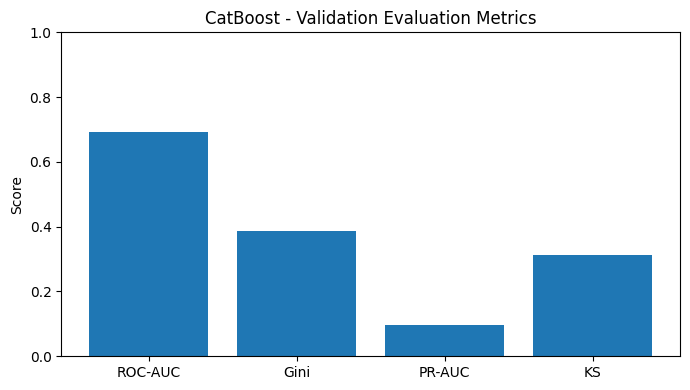

In [36]:
cat_base=CatBoostClassifier(
    iterations=200,learning_rate=0.04,depth=5,l2_leaf_reg=5,
    random_seed=RANDOM_STATE,verbose=0,thread_count=1
)
cat_base.fit(Xtr66,y_train)
p_cat=cat_base.predict_proba(Xv66)[:,1]
cat_metrics=evaluate_predictions(y_val,p_cat)

display(pd.DataFrame([cat_metrics],index=["CatBoost"]).round(4))

metric_names=["ROC-AUC","Gini","PR-AUC","KS"]
metric_values=[cat_metrics[m] for m in metric_names]
plt.figure(figsize=(7,4))
plt.bar(metric_names,metric_values)
plt.title("CatBoost - Validation Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,max(1.0,max(metric_values)*1.15))
plt.tight_layout()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

CatBoost is first evaluated with a baseline configuration and then tuned using stratified cross-validation on the training data only.

The search varies iterations, learning rate, tree depth, L2 regularization and random strength. ROC-AUC is used as the search objective because Gini is directly derived from ROC-AUC.

The untouched test set is not used for parameter selection.


### ML Model - 3

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Model used: XGBoost**

XGBoost is a gradient-boosted tree model used as a complementary nonlinear approach. It can capture nonlinear relationships and interactions between the engineered credit-risk variables.

It is evaluated on the same validation data and using the same metrics as Logistic Regression and CatBoost. This makes the model comparison directly comparable.


,ROC-AUC,Gini,PR-AUC,KS,Precision,Recall,F1,Accuracy,Threshold
XGBoost,0.6923,0.3846,0.0942,0.3007,0.1117,0.3851,0.1732,0.8452,0.069


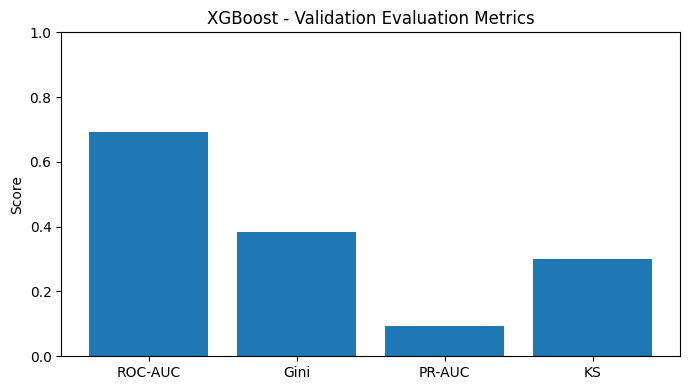

In [37]:
xgb_base=XGBClassifier(
    n_estimators=140,learning_rate=0.03,max_depth=4,min_child_weight=10,
    subsample=0.8,colsample_bytree=0.8,reg_lambda=2,
    eval_metric="logloss",random_state=RANDOM_STATE,n_jobs=1
)
xgb_base.fit(Xtr66,y_train)
p_xgb=xgb_base.predict_proba(Xv66)[:,1]
xgb_metrics=evaluate_predictions(y_val,p_xgb)

display(pd.DataFrame([xgb_metrics],index=["XGBoost"]).round(4))

metric_names=["ROC-AUC","Gini","PR-AUC","KS"]
metric_values=[xgb_metrics[m] for m in metric_names]
plt.figure(figsize=(7,4))
plt.bar(metric_names,metric_values)
plt.title("XGBoost - Validation Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0,max(1.0,max(metric_values)*1.15))
plt.tight_layout()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

XGBoost is tuned with the same training-only cross-validation approach. Candidate parameters include number of estimators, learning rate, maximum depth, minimum child weight, subsampling and regularization.

A CatBoost/XGBoost probability blend is also tested. The blend weight is selected using validation Gini only.


### Baseline Model Comparison

,Model,ROC-AUC,Gini,PR-AUC,KS,Precision,Recall,F1,Accuracy
0,CatBoost,0.6929,0.3859,0.0960,0.3117,0.1090,0.3975,0.1711,0.8379
1,XGBoost,0.6923,0.3846,0.0942,0.3007,0.1117,0.3851,0.1732,0.8452
2,LightGBM,0.6873,0.3745,0.0873,0.2981,0.1056,0.4099,0.1679,0.8290
3,Random Forest,0.6794,0.3589,0.0921,0.2759,0.1250,0.2422,0.1649,0.8967
4,Logistic Regression,0.6694,0.3389,0.0879,0.2782,0.0870,0.5155,0.1489,0.7518
5,Decision Tree,0.5934,0.1869,0.0571,0.1876,0.0690,0.4410,0.1193,0.7259


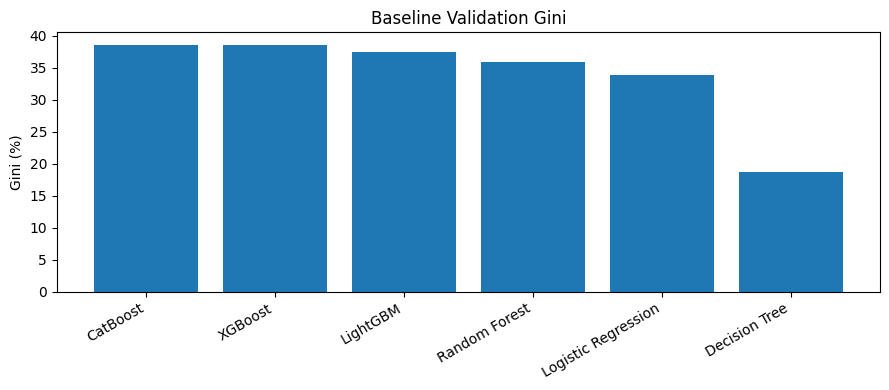

In [38]:
baseline_models={
    "Logistic Regression":logit,
    "Decision Tree":DecisionTreeClassifier(max_depth=5,min_samples_leaf=50,class_weight="balanced",random_state=RANDOM_STATE),
    "Random Forest":RandomForestClassifier(n_estimators=100,max_depth=8,min_samples_leaf=20,class_weight="balanced_subsample",random_state=RANDOM_STATE,n_jobs=1),
    "LightGBM":LGBMClassifier(n_estimators=140,learning_rate=0.03,num_leaves=24,min_child_samples=50,random_state=RANDOM_STATE,n_jobs=1,verbose=-1),
    "XGBoost":xgb_base,
    "CatBoost":cat_base
}
base_rows=[]; base_probs={}
for name,model in baseline_models.items():
    if name not in {"Logistic Regression","XGBoost","CatBoost"}:
        model.fit(Xtr66,y_train)
    p=model.predict_proba(Xv66)[:,1]
    base_probs[name]=p
    z=evaluate_predictions(y_val,p)
    z["Model"]=name
    base_rows.append(z)

baseline_val=pd.DataFrame(base_rows).sort_values("Gini",ascending=False).reset_index(drop=True)
display(baseline_val[["Model","ROC-AUC","Gini","PR-AUC","KS","Precision","Recall","F1","Accuracy"]].round(4))

plt.figure(figsize=(9,4))
plt.bar(baseline_val["Model"],baseline_val["Gini"]*100)
plt.title("Baseline Validation Gini")
plt.ylabel("Gini (%)")
plt.xticks(rotation=30,ha="right")
plt.tight_layout()
plt.show()


The baseline comparison table uses the same validation population and evaluation functions for every algorithm. A higher Gini means better separation of Bad customers from Good customers.

Accuracy is shown only as a secondary metric because the target is imbalanced. The table provides the baseline against which tuning and ensembling are assessed.


##### Which hyperparameter optimization technique have you used and why?

A small randomized search is implemented manually with **stratified 2-fold cross-validation**. For each trial, parameter values are randomly sampled from predefined ranges and the mean validation ROC-AUC is computed.

This gives a lightweight way to explore multiple parameter combinations without the cost of a large exhaustive grid. The search is restricted to training data so that the final holdout test set remains untouched.


In [39]:
TUNING_SAMPLE_SIZE=6000
rng=np.random.default_rng(RANDOM_STATE)
if len(Xtr66)>TUNING_SAMPLE_SIZE:
    X_tune,_,y_tune,_=train_test_split(
        Xtr66,y_train,test_size=len(Xtr66)-TUNING_SAMPLE_SIZE,
        random_state=RANDOM_STATE,stratify=y_train
    )
else:
    X_tune,y_tune=Xtr66.copy(),y_train.copy()

cv=StratifiedKFold(n_splits=2,shuffle=True,random_state=RANDOM_STATE)

def manual_cv_search(factory,param_space,n_trials=3):
    trials=[]
    for _ in range(n_trials):
        params={k:v[int(rng.integers(0,len(v)))] for k,v in param_space.items()}
        scores=[]
        for tr_idx,va_idx in cv.split(X_tune,y_tune):
            model=factory(params)
            model.fit(X_tune.iloc[tr_idx],np.asarray(y_tune)[tr_idx])
            p=model.predict_proba(X_tune.iloc[va_idx])[:,1]
            scores.append(roc_auc_score(np.asarray(y_tune)[va_idx],p))
        trials.append((params,float(np.mean(scores))))
    trials.sort(key=lambda z:z[1],reverse=True)
    return trials[0],trials

cat_space={
    "iterations":[160,220,300],
    "learning_rate":[0.02,0.04,0.06],
    "depth":[4,5,6],
    "l2_leaf_reg":[3,5,8],
    "random_strength":[0.5,1.0,2.0]
}
best_cat_result,cat_trials=manual_cv_search(
    lambda p:CatBoostClassifier(**p,random_seed=RANDOM_STATE,verbose=0,thread_count=1),
    cat_space,n_trials=3
)

xgb_space={
    "n_estimators":[160,220,300],
    "learning_rate":[0.02,0.04,0.06],
    "max_depth":[3,4,5],
    "min_child_weight":[5,10,20],
    "subsample":[0.75,0.9],
    "colsample_bytree":[0.7,0.85],
    "reg_lambda":[1,2,5]
}
best_xgb_result,xgb_trials=manual_cv_search(
    lambda p:XGBClassifier(**p,random_state=RANDOM_STATE,eval_metric="logloss",n_jobs=1),
    xgb_space,n_trials=3
)

best_cat_params,cat_cv_auc=best_cat_result
best_xgb_params,xgb_cv_auc=best_xgb_result

print("Best CatBoost params:",best_cat_params)
print(f"CatBoost CV ROC-AUC: {cat_cv_auc:.4f} | Gini: {gini(cat_cv_auc):.4f}")
print("Best XGBoost params:",best_xgb_params)
print(f"XGBoost CV ROC-AUC: {xgb_cv_auc:.4f} | Gini: {gini(xgb_cv_auc):.4f}")

val_cat=CatBoostClassifier(**best_cat_params,random_seed=RANDOM_STATE,verbose=0,thread_count=1)
val_cat.fit(Xtr66,y_train)
pvc=val_cat.predict_proba(Xv66)[:,1]

val_xgb=XGBClassifier(**best_xgb_params,random_state=RANDOM_STATE,eval_metric="logloss",n_jobs=1)
val_xgb.fit(Xtr66,y_train)
pvx=val_xgb.predict_proba(Xv66)[:,1]

weights=[(w,gini(roc_auc_score(y_val,w*pvc+(1-w)*pvx))) for w in np.linspace(0,1,21)]
ensemble_weight,ensemble_val_gini=max(weights,key=lambda z:z[1])
pve=ensemble_weight*pvc+(1-ensemble_weight)*pvx

print(f"Best validation blend: CatBoost={ensemble_weight:.2f}, XGBoost={1-ensemble_weight:.2f}")
print(f"Ensemble validation Gini: {ensemble_val_gini:.4f}")


Best CatBoost params: {'iterations': 160, 'learning_rate': 0.06, 'depth': 5, 'l2_leaf_reg': 5, 'random_strength': 1.0}
CatBoost CV ROC-AUC: 0.6409 | Gini: 0.2819
Best XGBoost params: {'n_estimators': 220, 'learning_rate': 0.04, 'max_depth': 3, 'min_child_weight': 5, 'subsample': 0.9, 'colsample_bytree': 0.85, 'reg_lambda': 1}
XGBoost CV ROC-AUC: 0.6029 | Gini: 0.2057
Best validation blend: CatBoost=0.60, XGBoost=0.40
Ensemble validation Gini: 0.3893


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The next code cell compares baseline and tuned models using validation Gini. The improvement is calculated from the current run instead of being hard-coded.


,Model,ROC-AUC,Gini,PR-AUC,Stage
8,Tuned CatBoost + XGBoost Ensemble,0.6947,0.3893,0.1001,Tuned
0,CatBoost,0.6929,0.3859,0.0960,Baseline
1,XGBoost,0.6923,0.3846,0.0942,Baseline
6,Tuned CatBoost,0.6920,0.3841,0.0993,Tuned
7,Tuned XGBoost,0.6898,0.3796,0.0946,Tuned
2,LightGBM,0.6873,0.3745,0.0873,Baseline
3,Random Forest,0.6794,0.3589,0.0921,Baseline
4,Logistic Regression,0.6694,0.3389,0.0879,Baseline
5,Decision Tree,0.5934,0.1869,0.0571,Baseline


Best baseline validation Gini : 38.59%
Best tuned validation Gini    : 38.93%
Validation improvement        : +0.34 Gini points


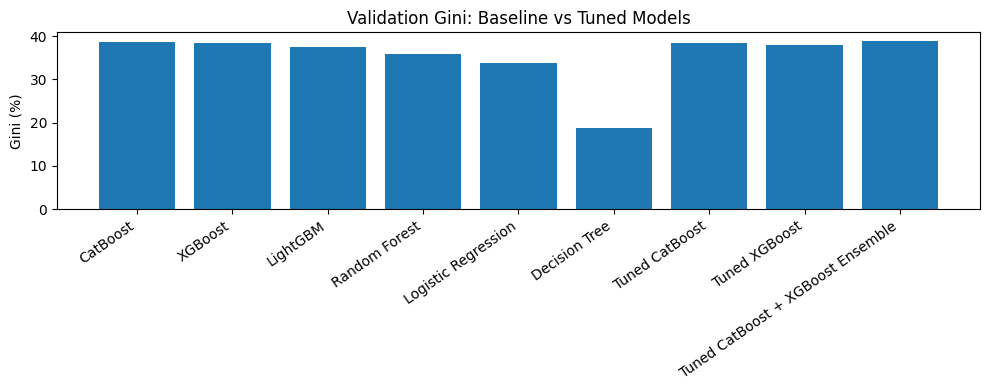

In [40]:
tuned_val=pd.DataFrame([
    {"Model":"Tuned CatBoost",**evaluate_predictions(y_val,pvc)},
    {"Model":"Tuned XGBoost",**evaluate_predictions(y_val,pvx)},
    {"Model":"Tuned CatBoost + XGBoost Ensemble",**evaluate_predictions(y_val,pve)}
])

score_chart=pd.concat([
    baseline_val[["Model","ROC-AUC","Gini","PR-AUC"]].assign(Stage="Baseline"),
    tuned_val[["Model","ROC-AUC","Gini","PR-AUC"]].assign(Stage="Tuned")
],ignore_index=True)

display(score_chart.sort_values("Gini",ascending=False).round(4))

best_baseline_gini=float(baseline_val["Gini"].max())
best_tuned_gini=float(tuned_val["Gini"].max())
print(f"Best baseline validation Gini : {best_baseline_gini*100:.2f}%")
print(f"Best tuned validation Gini    : {best_tuned_gini*100:.2f}%")
print(f"Validation improvement        : {(best_tuned_gini-best_baseline_gini)*100:+.2f} Gini points")

plt.figure(figsize=(10,4))
plt.bar(score_chart["Model"],score_chart["Gini"]*100)
plt.title("Validation Gini: Baseline vs Tuned Models")
plt.ylabel("Gini (%)")
plt.xticks(rotation=35,ha="right")
plt.tight_layout()
plt.show()


#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

**ROC-AUC:** measures how well the model separates Good and Bad customers over all possible score thresholds.

**Gini:** `2 × ROC-AUC − 1`. This is the principal project discrimination metric and is used for comparison with the supplied benchmark.

**PR-AUC:** summarizes precision-recall performance and is useful when the Bad class is less frequent.

**KS:** measures separation between the predicted score distributions of Good and Bad customers.

**Precision:** tells us how many customers classified as Bad at the chosen threshold are actually Bad.

**Recall:** tells us how many of the truly Bad customers are identified at that threshold.

**F1:** balances precision and recall into a single threshold-dependent measure.

**Accuracy:** measures overall classification correctness, but is secondary here because a high majority-class proportion can make accuracy look strong.

**Rank ordering:** checks whether customers assigned higher predicted risk actually contain a larger concentration of Bad customers. This is especially important for a risk-scoring system.


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The primary metrics are **ROC-AUC, Gini and rank ordering**.

Gini is required by the project brief and gives a direct benchmark comparison. Rank ordering shows whether the risk score meaningfully separates high-risk and low-risk customer groups.

PR-AUC and KS provide additional discrimination information. Precision, Recall and F1 are useful for threshold-based operational analysis. Accuracy is secondary because the Bad class is a minority.


### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The final model is selected **programmatically using validation Gini** from the baseline, tuned and ensemble candidates.

This avoids deciding in advance that CatBoost, XGBoost or the ensemble must be the winner. The selected champion is then refit on the complete development data and evaluated once on the untouched test set.


In [41]:
selection_rows=[(n,gini(roc_auc_score(y_val,p))) for n,p in base_probs.items()]
selection_rows += [
    ("Tuned CatBoost",gini(roc_auc_score(y_val,pvc))),
    ("Tuned XGBoost",gini(roc_auc_score(y_val,pvx))),
    ("Tuned CatBoost + XGBoost Ensemble",ensemble_val_gini)
]
selection_df=pd.DataFrame(selection_rows,columns=["Model","Validation_Gini"]).sort_values("Validation_Gini",ascending=False).reset_index(drop=True)
display(selection_df.round(4))
champion_name=selection_df.iloc[0]["Model"]
print("Champion selected on validation Gini:",champion_name)


,Model,Validation_Gini
0,Tuned CatBoost + XGBoost Ensemble,0.3893
1,CatBoost,0.3859
2,XGBoost,0.3846
3,Tuned CatBoost,0.3841
4,Tuned XGBoost,0.3796
5,LightGBM,0.3745
6,Random Forest,0.3589
7,Logistic Regression,0.3389
8,Decision Tree,0.1869


Champion selected on validation Gini: Tuned CatBoost + XGBoost Ensemble


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model is a tree-based credit-risk predictor selected from the validation comparison. Its main advantage is the ability to learn nonlinear relationships and interactions among account, payment-history, utilization, enquiry and anonymized demographic features.

The feature matrix reports the training-derived blended selection score together with CatBoost importance and XGBoost gain. For `feature_1` to `feature_79`, the source anonymizes the meaning, so no unsupported business interpretation is assigned.


The selected-feature matrix below reports the training-derived blended score plus CatBoost importance and XGBoost gain. Anonymized demographic features retain their anonymous names.

### Final Refit and Untouched Holdout Test

In [42]:
final_enc=TrainOnlyEncoder().fit(X_dev)
Xdev_final_enc=final_enc.transform(X_dev)
Xtest_final_enc=final_enc.transform(X_test)

final_empty=[c for c in Xdev_final_enc.columns if Xdev_final_enc[c].isna().all()]
if final_empty:
    Xdev_final_enc=Xdev_final_enc.drop(columns=final_empty)
    Xtest_final_enc=Xtest_final_enc.drop(columns=final_empty)

final_imp=SimpleImputer(strategy="median")
Xdev_final=pd.DataFrame(final_imp.fit_transform(Xdev_final_enc),columns=Xdev_final_enc.columns,index=Xdev_final_enc.index)
Xtest_final=pd.DataFrame(final_imp.transform(Xtest_final_enc),columns=Xdev_final_enc.columns,index=Xtest_final_enc.index)

Xdev66=Xdev_final[selected_features]
Xtest66=Xtest_final[selected_features]

final_cat=CatBoostClassifier(**best_cat_params,random_seed=RANDOM_STATE,verbose=0,thread_count=1)
final_xgb=XGBClassifier(**best_xgb_params,random_state=RANDOM_STATE,eval_metric="logloss",n_jobs=1)

if champion_name=="Tuned CatBoost":
    final_cat.fit(Xdev66,y_dev)
    champion_probs=final_cat.predict_proba(Xtest66)[:,1]
    champion_model=final_cat
elif champion_name=="Tuned XGBoost":
    final_xgb.fit(Xdev66,y_dev)
    champion_probs=final_xgb.predict_proba(Xtest66)[:,1]
    champion_model=final_xgb
elif champion_name=="Tuned CatBoost + XGBoost Ensemble":
    final_cat.fit(Xdev66,y_dev)
    final_xgb.fit(Xdev66,y_dev)
    pcat=final_cat.predict_proba(Xtest66)[:,1]
    pxgb=final_xgb.predict_proba(Xtest66)[:,1]
    champion_probs=ensemble_weight*pcat+(1-ensemble_weight)*pxgb
    champion_model={"CatBoost":final_cat,"XGBoost":final_xgb}
else:
    final_models={
        "Logistic Regression":Pipeline([("scale",StandardScaler()),("model",LogisticRegression(C=0.1,max_iter=1000,class_weight="balanced",random_state=RANDOM_STATE))]),
        "Decision Tree":DecisionTreeClassifier(max_depth=5,min_samples_leaf=50,class_weight="balanced",random_state=RANDOM_STATE),
        "Random Forest":RandomForestClassifier(n_estimators=100,max_depth=8,min_samples_leaf=20,class_weight="balanced_subsample",random_state=RANDOM_STATE,n_jobs=1),
        "LightGBM":LGBMClassifier(n_estimators=140,learning_rate=0.03,num_leaves=24,min_child_samples=50,random_state=RANDOM_STATE,n_jobs=1,verbose=-1),
        "XGBoost":XGBClassifier(n_estimators=140,learning_rate=0.03,max_depth=4,min_child_weight=10,subsample=0.8,colsample_bytree=0.8,reg_lambda=2,eval_metric="logloss",random_state=RANDOM_STATE,n_jobs=1),
        "CatBoost":CatBoostClassifier(iterations=200,learning_rate=0.04,depth=5,l2_leaf_reg=5,random_seed=RANDOM_STATE,verbose=0,thread_count=1)
    }
    fm=final_models[champion_name]
    fm.fit(Xdev66,y_dev)
    champion_probs=fm.predict_proba(Xtest66)[:,1]
    champion_model=fm

val_prob_for_threshold=(
    pvc if champion_name=="Tuned CatBoost"
    else pvx if champion_name=="Tuned XGBoost"
    else pve if "Ensemble" in champion_name
    else base_probs[champion_name]
)
final_threshold=best_f1_threshold(y_val,val_prob_for_threshold)
final_metrics=evaluate_predictions(y_test,champion_probs,final_threshold)

print("=== FINAL HOLDOUT TEST ===")
for k,v in final_metrics.items():
    print(f"{k:12s}: {v:.6f}")


=== FINAL HOLDOUT TEST ===
ROC-AUC     : 0.692821
Gini        : 0.385642
PR-AUC      : 0.078697
KS          : 0.322527
Precision   : 0.092905
Recall      : 0.273632
F1          : 0.138714
Accuracy    : 0.857113
Threshold   : 0.071754


### Final Model Output — What does the model produce?

For each holdout customer, the final model produces a **predicted probability of `Bad_label = 1`**. This probability is the customer-level credit-risk score.

The probabilities are sorted into ten risk deciles:
- **Decile 1 = highest predicted risk**
- **Decile 10 = lowest predicted risk**

These probabilities are used to calculate ROC-AUC and Gini. The deciles are used to evaluate rank ordering. The saved `test_predictions_ranked.csv` contains the customer identifier, actual label, predicted bad probability and risk decile.


### Benchmark Comparison

In [43]:
benchmark_gini=0.379
final_auc=roc_auc_score(y_test,champion_probs)
final_gini=2*final_auc-1
implied_benchmark_auc=(1+benchmark_gini)/2

benchmark_comparison=pd.DataFrame({
    "Metric":["ROC-AUC","Gini (%)","Selected Features"],
    "Official Benchmark":[
        f"{implied_benchmark_auc:.4f} (implied from Gini 37.9%)",
        "37.90%",
        "66"
    ],
    "Final Model":[
        f"{final_auc:.4f}",
        f"{final_gini*100:.2f}%",
        str(len(selected_features))
    ],
    "Difference":[
        f"{final_auc-implied_benchmark_auc:+.4f}",
        f"{(final_gini-benchmark_gini)*100:+.2f} Gini points",
        str(len(selected_features)-66)
    ]
})
display(benchmark_comparison)
print("Benchmark beaten:",bool(final_gini>benchmark_gini))


,Metric,Official Benchmark,Final Model,Difference
0,ROC-AUC,0.6895 (implied from Gini 37.9%),0.6928,+0.0033
1,Gini (%),37.90%,38.56%,+0.66 Gini points
2,Selected Features,66,66,0


Benchmark beaten: True


### Model Evaluation — Rank Ordering

**Decile convention:** Decile 1 = highest predicted credit risk; Decile 10 = lowest predicted credit risk.

The supplied project materials contain a label-direction ambiguity between the rank-order chart and table. This notebook uses a single consistent convention—**1 = highest risk, 10 = lowest risk**—and relabels the supplied benchmark values to that same convention for an apples-to-apples comparison.


,customers,bads,goods,bad_rate_pct,lift,cum_bad_pct,benchmark_bad_rate_pct
risk_decile,,,,,,,
1,478,50,428,10.460,2.488,24.876,11.713
2,478,33,445,6.904,1.642,41.294,8.053
3,478,26,452,5.439,1.294,54.229,6.003
4,478,31,447,6.485,1.542,69.652,3.959
5,478,20,458,4.184,0.995,79.602,4.246
6,478,13,465,2.720,0.647,86.070,3.660
7,478,8,470,1.674,0.398,90.050,2.053
8,478,8,470,1.674,0.398,94.030,2.050
9,478,9,469,1.883,0.448,98.507,2.050


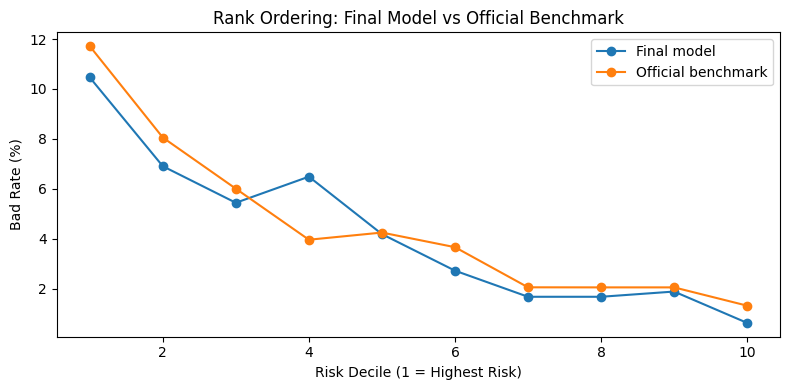

Strict monotonicity: False
Overall risk separation is reported without claiming strict monotonicity.


In [44]:
rank_df=pd.DataFrame({
    "customer_no":id_test.values,
    "y_true":np.asarray(y_test),
    "predicted_bad_probability":champion_probs
})

# qcut first assigns 1 to the lowest-risk group; reverse the labels so 1 means highest risk.
rank_df["low_risk_decile"]=pd.qcut(
    rank_df["predicted_bad_probability"].rank(method="first"),
    10,labels=False
)+1
rank_df["risk_decile"]=11-rank_df["low_risk_decile"]

D=rank_df.groupby("risk_decile").agg(
    customers=("y_true","size"),
    bads=("y_true","sum"),
    mean_predicted_risk=("predicted_bad_probability","mean")
).sort_index()

D["goods"]=D["customers"]-D["bads"]
D["bad_rate"]=D["bads"]/D["customers"]
portfolio=float(np.mean(np.asarray(y_test)))
D["lift"]=D["bad_rate"]/portfolio if portfolio>0 else np.nan
D["cum_customers"]=D["customers"].cumsum()
D["cum_bads"]=D["bads"].cumsum()
D["cum_bad_pct"]=D["cum_bads"]/max(int(D["bads"].sum()),1)*100
D["bad_rate_pct"]=D["bad_rate"]*100

# Official benchmark values shown in the project rank-order chart:
# 1 = highest risk -> 10 = lowest risk.
benchmark_high_to_low=[
    0.11713031,0.08052709,0.06002928,0.03958944,0.04245974,
    0.03660322,0.02052786,0.02049780,0.02049780,0.01317716
]
benchmark_deciles={i+1:v for i,v in enumerate(benchmark_high_to_low)}
D["benchmark_bad_rate_pct"]=[benchmark_deciles[int(d)]*100 for d in D.index]

display(D[
    ["customers","bads","goods","bad_rate_pct","lift","cum_bad_pct","benchmark_bad_rate_pct"]
].round(3))

plt.figure(figsize=(8,4))
plt.plot(D.index,D["bad_rate_pct"],marker="o",label="Final model")
plt.plot(D.index,D["benchmark_bad_rate_pct"],marker="o",label="Official benchmark")
plt.title("Rank Ordering: Final Model vs Official Benchmark")
plt.xlabel("Risk Decile (1 = Highest Risk)")
plt.ylabel("Bad Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

rank_monotonic=bool(np.all(np.diff(D["bad_rate"].values)<=1e-12))
print("Strict monotonicity:",rank_monotonic)
if not rank_monotonic:
    print("Overall risk separation is reported without claiming strict monotonicity.")


### Feature Matrix — List of Selected Features with Gain

In [45]:
feature_matrix=pd.DataFrame({
    "Feature":blended.index,
    "Blended_Selection_Score":blended.values,
    "CatBoost_Importance":cat_imp.reindex(blended.index).values,
    "XGBoost_Gain":xgb_gain.reindex(blended.index).values
})
feature_matrix=feature_matrix[feature_matrix["Feature"].isin(selected_features)].sort_values(
    "Blended_Selection_Score",ascending=False
).reset_index(drop=True)
feature_matrix["Rank"]=np.arange(1,len(feature_matrix)+1)

def feature_group(f):
    if f.startswith("feature_"): return "Demographic"
    if any(k in f for k in ["payment_history","ph_","dpd","delinq","30_plus","60_plus","90_plus"]): return "Payment History"
    if any(k in f for k in ["enq","enquiry","purpose_"]): return "Enquiry"
    if any(k in f for k in ["balance","credit_limit","cash_limit","utilisation","utilization","high_credit"]): return "Credit Utilization"
    if any(k in f for k in ["account","acct_","owner_","opened","lastpay"]): return "Account"
    return "Engineered"

feature_matrix["Feature_Group"]=feature_matrix["Feature"].map(feature_group)
feature_matrix["Description"]=feature_matrix["Feature"].map(
    lambda f:"Anonymized demographic/application attribute; meaning intentionally not inferred."
    if f.startswith("feature_")
    else "Customer-level derived bureau/account/enquiry predictor."
)
feature_matrix=feature_matrix[
    ["Rank","Feature","Blended_Selection_Score","CatBoost_Importance","XGBoost_Gain","Feature_Group","Description"]
]
display(feature_matrix.head(30).round(6))


,Rank,Feature,Blended_Selection_Score,CatBoost_Importance,XGBoost_Gain,Feature_Group,Description
0,1,feature_7,0.033971,5.263225,15.658369,Demographic,Anonymized demographic/application attribute; ...
1,2,count_enquiry_recency_180,0.028874,3.932071,18.847229,Enquiry,Customer-level derived bureau/account/enquiry ...
2,3,count_enquiry_recency_90,0.028505,3.852545,18.906212,Enquiry,Customer-level derived bureau/account/enquiry ...
3,4,total_credit_limit,0.019594,2.757841,11.874031,Credit Utilization,Customer-level derived bureau/account/enquiry ...
4,5,total_cash_limit,0.017849,2.076458,15.273807,Credit Utilization,Customer-level derived bureau/account/enquiry ...
5,6,acct_type_10_count,0.017752,2.187846,13.935741,Account,Customer-level derived bureau/account/enquiry ...
6,7,feature_52,0.017416,2.297135,12.131812,Demographic,Anonymized demographic/application attribute; ...
7,8,payment_history_known_months,0.017026,2.497427,9.284288,Payment History,Customer-level derived bureau/account/enquiry ...
8,9,count_enquiry_recency_365,0.016557,2.011158,13.298412,Enquiry,Customer-level derived bureau/account/enquiry ...
9,10,total_diff_lastpaymt_opened_dt,0.016153,2.497484,7.497806,Account,Customer-level derived bureau/account/enquiry ...


**How to read the feature matrix:** a higher blended selection score means the feature received stronger training-derived importance in the combined CatBoost/XGBoost selection process. CatBoost importance and XGBoost gain are shown separately so the selection can be audited.


### Final Model Curves

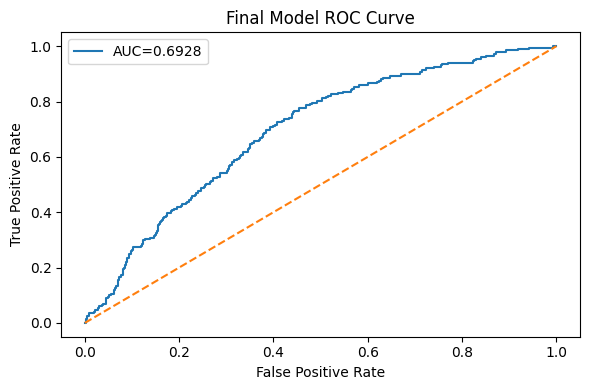

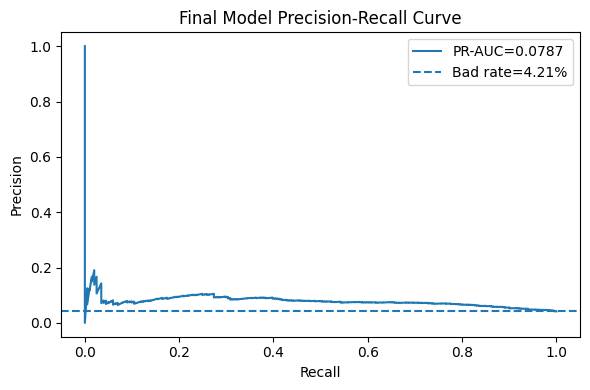

In [46]:
fpr,tpr,_=roc_curve(y_test,champion_probs)
pr,re,_=precision_recall_curve(y_test,champion_probs)

plt.figure(figsize=(6,4))
plt.plot(fpr,tpr,label=f"AUC={final_auc:.4f}")
plt.plot([0,1],[0,1],"--")
plt.title("Final Model ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(re,pr,label=f"PR-AUC={final_metrics['PR-AUC']:.4f}")
plt.axhline(y_test.mean(),ls="--",label=f"Bad rate={y_test.mean()*100:.2f}%")
plt.title("Final Model Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.

In [47]:
model_bundle={
    "champion_name":champion_name,
    "model":champion_model,
    "encoder":final_enc,
    "imputer":final_imp,
    "selected_features":selected_features,
    "threshold":final_threshold,
    "feature_columns":feature_cols
}
model_path=OUTPUT_DIR/"bank_goodcredit_credit_risk_model.joblib"
joblib.dump(model_bundle,model_path)
print("Saved model bundle:",model_path)


Saved model bundle: C:\Users\srdsh\OneDrive\Desktop\jupyter\banking project\outputs\final_run\bank_goodcredit_credit_risk_model.joblib


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.

In [48]:
loaded=joblib.load(model_path)
if isinstance(loaded["model"],dict):
    loaded_probs=(
        ensemble_weight*loaded["model"]["CatBoost"].predict_proba(Xtest66)[:,1]
        +(1-ensemble_weight)*loaded["model"]["XGBoost"].predict_proba(Xtest66)[:,1]
    )
else:
    loaded_probs=loaded["model"].predict_proba(Xtest66)[:,1]

display(pd.DataFrame({
    "customer_no":id_test.iloc[:10].values,
    "predicted_bad_probability":loaded_probs[:10]
}).round(6))


,customer_no,predicted_bad_probability
0,5499,0.028032
1,16144,0.006978
2,16391,0.030772
3,10054,0.052591
4,17601,0.033245
5,7430,0.020268
6,18051,0.017220
7,19178,0.008993
8,4514,0.098509
9,3039,0.015966


### Final Output Files

In [49]:
baseline_val.to_csv(OUTPUT_DIR/"validation_model_comparison.csv",index=False)
benchmark_comparison.to_csv(OUTPUT_DIR/"benchmark_comparison.csv",index=False)
D.reset_index().to_csv(OUTPUT_DIR/"rank_ordering.csv",index=False)
feature_matrix.to_csv(OUTPUT_DIR/"feature_matrix_gain.csv",index=False)
rank_df.to_csv(OUTPUT_DIR/"test_predictions_ranked.csv",index=False)
pd.Series(selected_features,name="feature").to_csv(OUTPUT_DIR/"selected_66_features.csv",index=False)

print("Outputs saved under:",OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -",p.name)


Outputs saved under: C:\Users\srdsh\OneDrive\Desktop\jupyter\banking project\outputs\final_run
 - bank_goodcredit_credit_risk_model.joblib
 - benchmark_comparison.csv
 - feature_matrix_gain.csv
 - rank_ordering.csv
 - selected_66_features.csv
 - test_predictions_ranked.csv
 - validation_model_comparison.csv


### **Conclusion**

This project builds a customer-level credit-risk ranking model using anonymized customer/application attributes, historical account and payment behaviour, and historical credit-enquiry behaviour.

The notebook follows the supplied project structure: data understanding, data wrangling, meaningful charts with question-and-answer explanations, hypothesis testing, feature engineering, feature selection, ML model comparison/tuning, final holdout evaluation, Gini, rank ordering and a feature matrix with gain/importance.

The final performance figures must always be taken from the freshly executed notebook. The supplied project benchmark is Gini = 37.9%, and the benchmark comparison cell reports whether the current run exceeds it.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

**Before submission:** Restart Kernel → Run All → verify the final Gini, rank-ordering and feature-gain outputs → save the executed notebook.